In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [2]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches

In [3]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/8sec_0overlap/data"

train_path = os.path.join(DATA_DIR, "SBP_FTEST_train.csv")
val_path   = os.path.join(DATA_DIR, "SBP_FTEST_val.csv")
test_path  = os.path.join(DATA_DIR, "SBP_FTEST_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (263103, 16)
Val:   (33223, 16)
Test:  (33347, 16)


In [4]:
TARGET = "SBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (263103, 15)
y_train: (263103,)
X_val:   (33223, 15)
y_val:   (33223,)
X_test:  (33347, 15)
y_test:  (33347,)


In [5]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/data/SBP_FTEST_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(2928374, 17)
   vpg_skewness   vpg_iqr  apg_zero_crossing_rate  vpg_energy_iqr  \
0     -0.554263  1.824971               -0.339146       -1.118971   
1     -0.573270  1.959556               -0.186419       -1.114600   
2     -0.644623  1.743451               -0.339146       -1.170703   
3     -0.709170  2.081286                0.959027       -1.029070   
4     -0.657449  2.041000                0.500849       -1.084830   

   apg_skewness  apg_shannon_entropy  apg_energy_iqr  vpg_shannon_entropy  \
0      2.973598            -0.082530       -0.544651             0.068754   
1      2.599054            -0.491994       -0.528804             0.333610   
2      2.823279             0.290188       -0.662262             0.399707   
3      2.647086             0.425392       -0.502680             0.474845   
4      2.868377             0.172152       -0.542259             0.371499   

    ppg_iqr  vpg_energy_skewness  vpg_kurtosis  vpg_kte_iqr   apg_iqr  \
0  0.766796            -0.276019   

In [6]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [7]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [8]:
print("SBP min:", y_train.min())
print("SBP max:", y_train.max())
print("SBP mean:", y_train.mean())
print("SBP std:", y_train.std())

print("SBP > 80:", np.sum(y_train > 80))
print("SBP > 90:", np.sum(y_train > 90))
print("SBP > 100:", np.sum(y_train > 100))

SBP min: 72.39897585370947
SBP max: 199.28414010847308
SBP mean: 129.94326592181736
SBP std: 22.027568517849353
SBP > 80: 262864
SBP > 90: 259096
SBP > 100: 243857


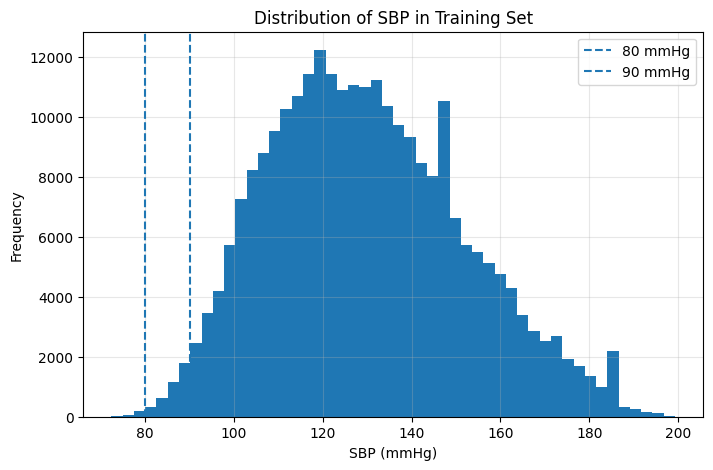

In [9]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("SBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of SBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: SBP
RMSE: 21.1305
MSE : 446.4962
R²  : 0.1546
MAE : 16.8790


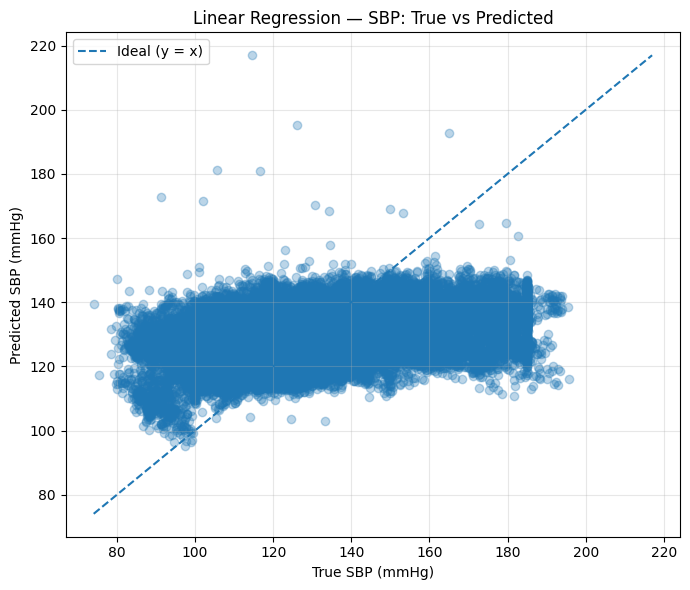

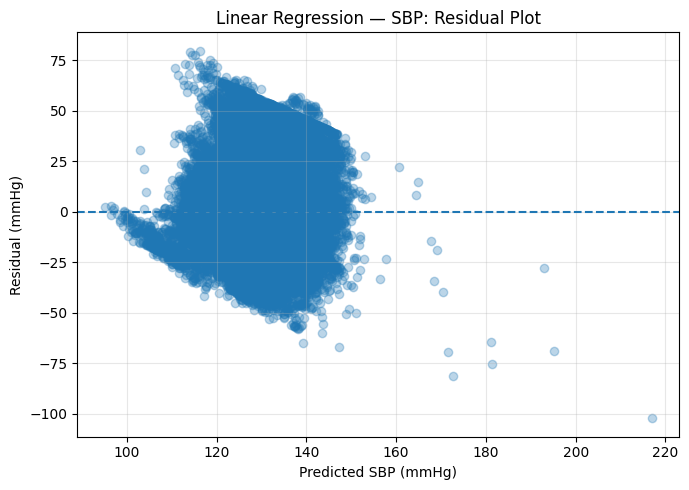

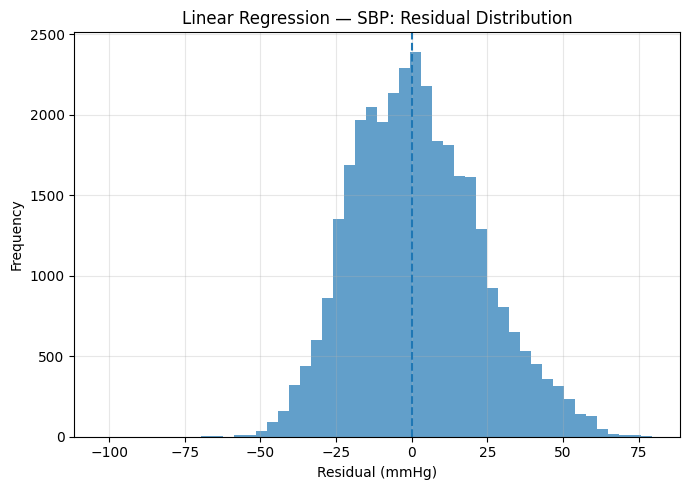

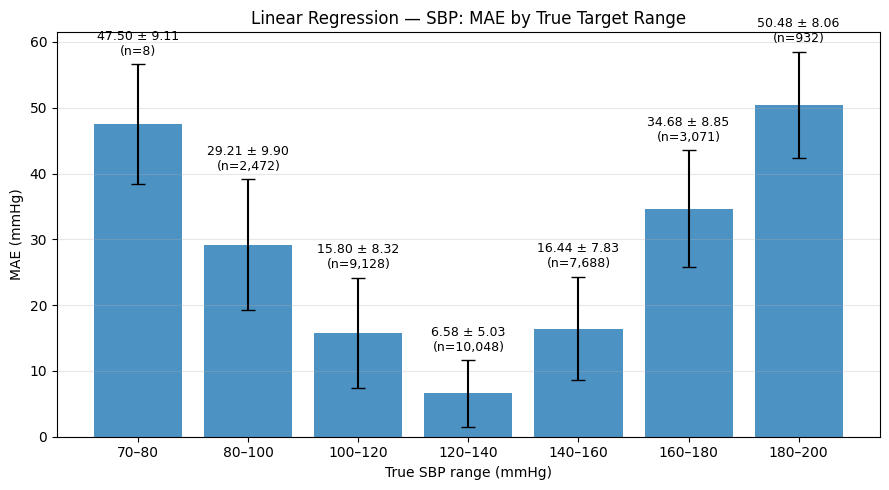

In [10]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 176.7749
MSE : 31249.3615
R²  : -72.3565
MAE : 34.9175


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


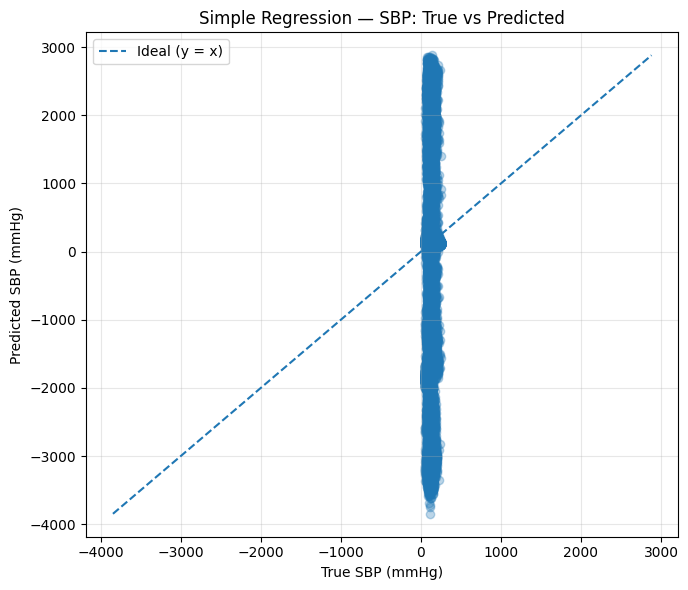

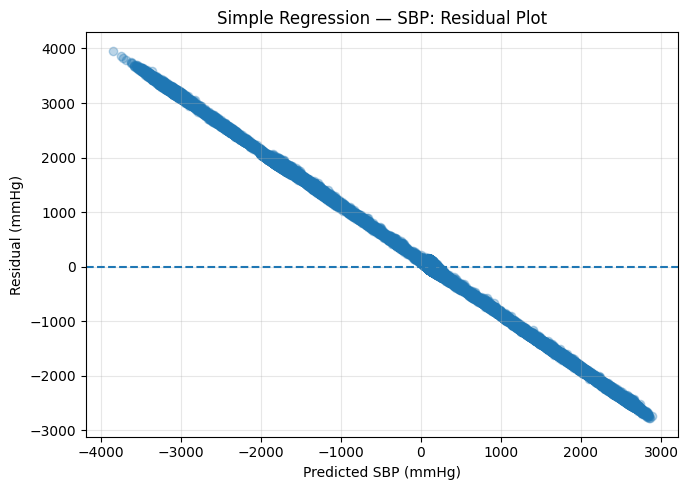

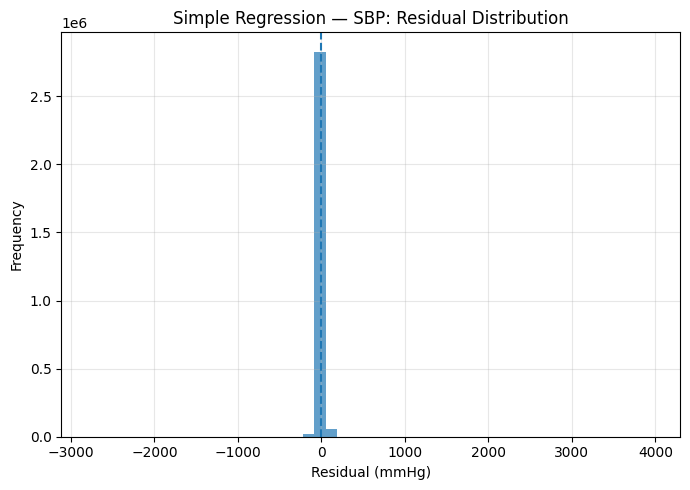

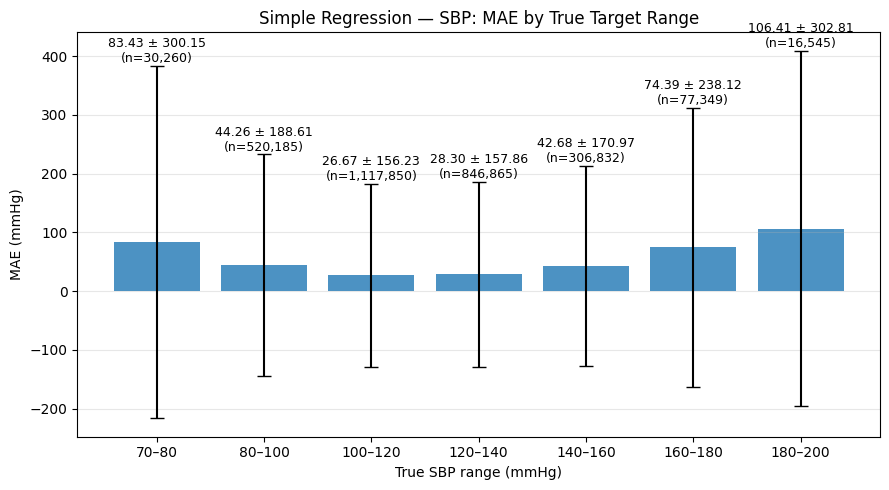

In [11]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — SBP
---------------------------------------------
RMSE: 20.3414
MSE : 413.7728
R²  : 0.2166
MAE : 16.0669


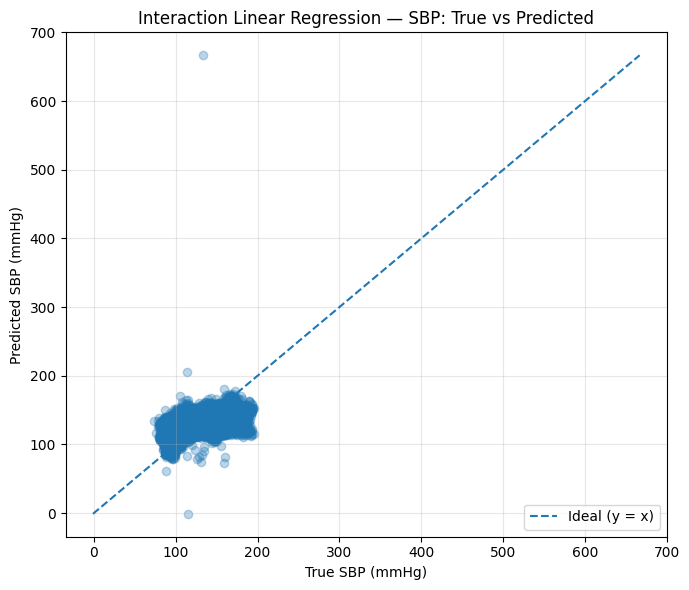

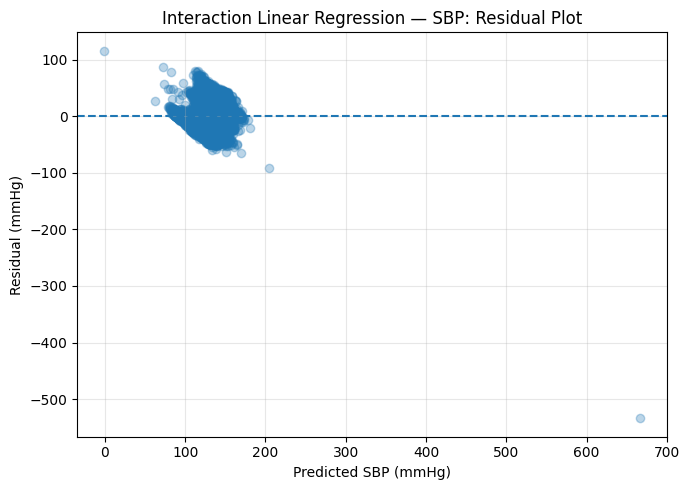

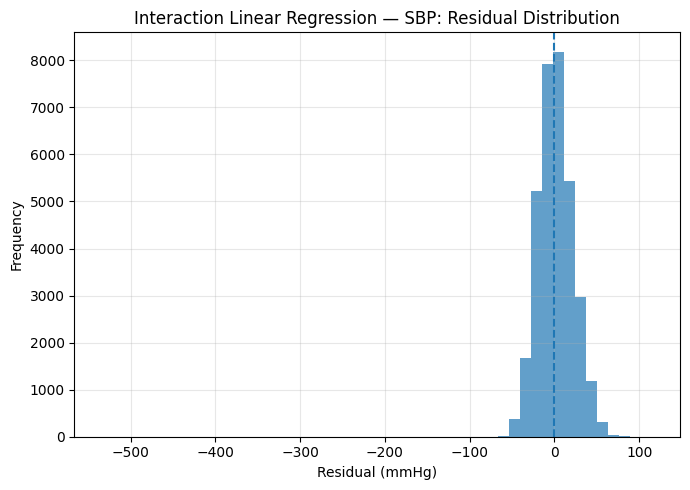

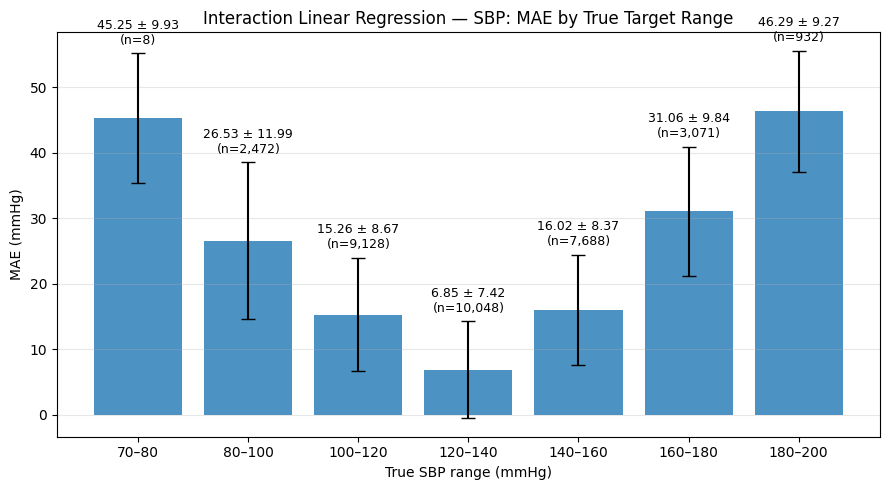

In [12]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 10213.8978
MSE : 104323708.6947
R²  : -244894.2464
MAE : 910.6430


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


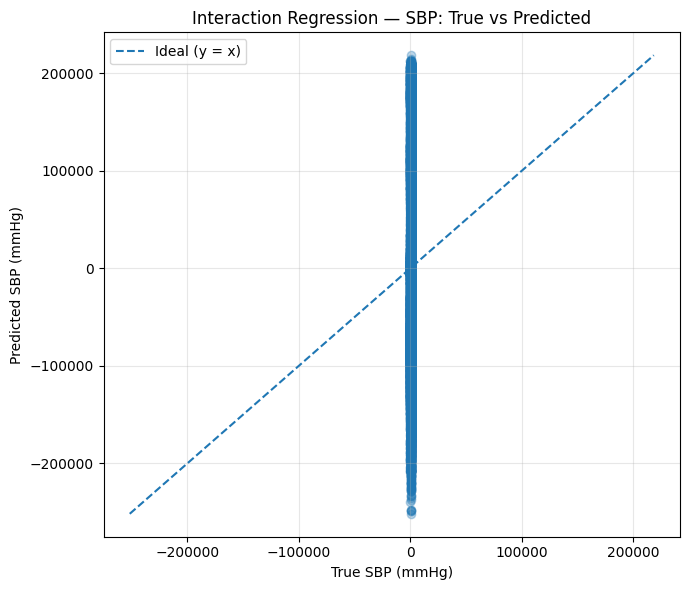

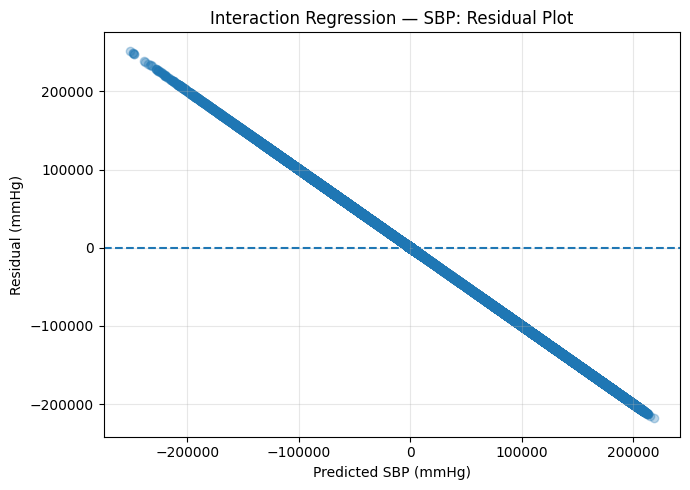

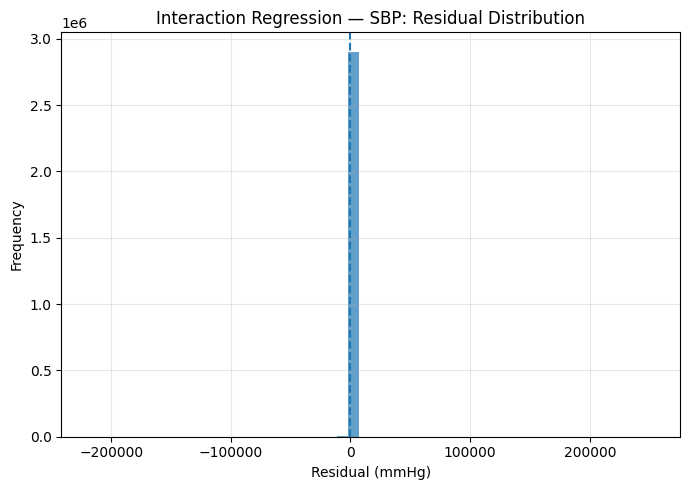

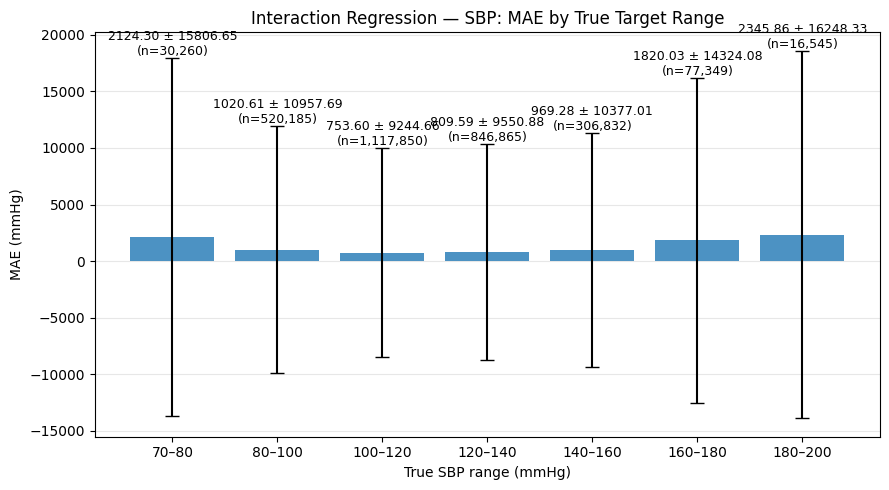

In [13]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — SBP
----------------------------------------
RMSE: 21.1589
MSE : 447.6994
R²  : 0.1523
MAE : 16.8594


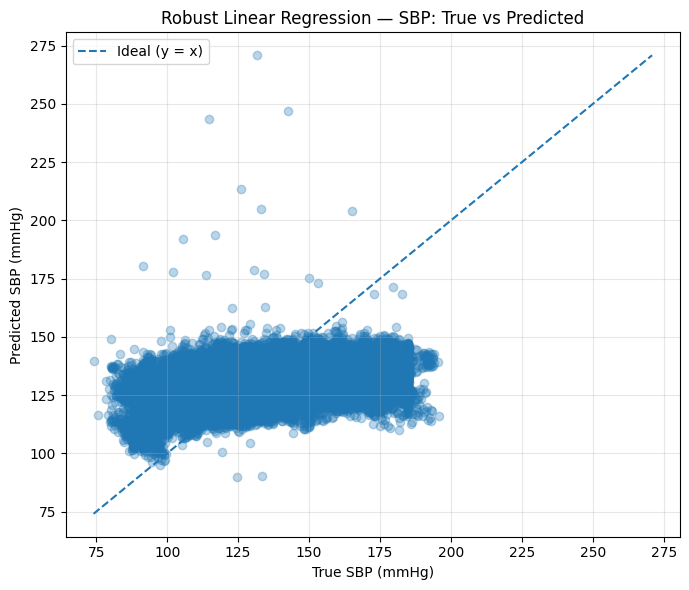

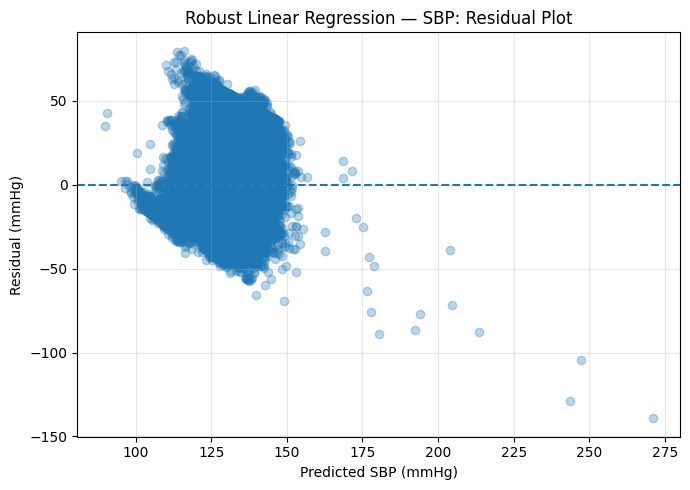

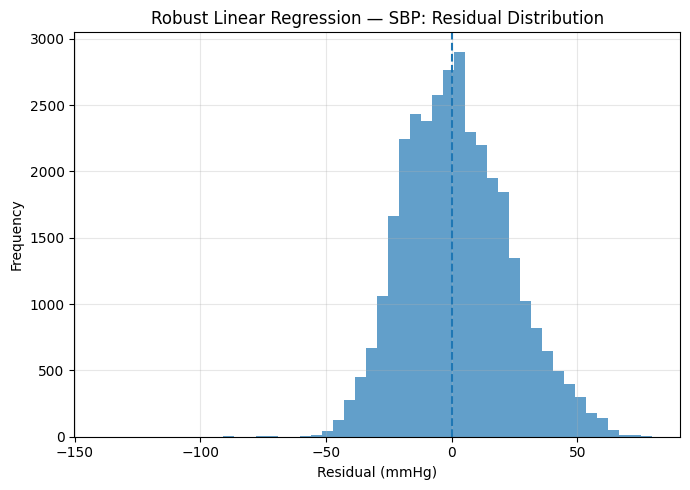

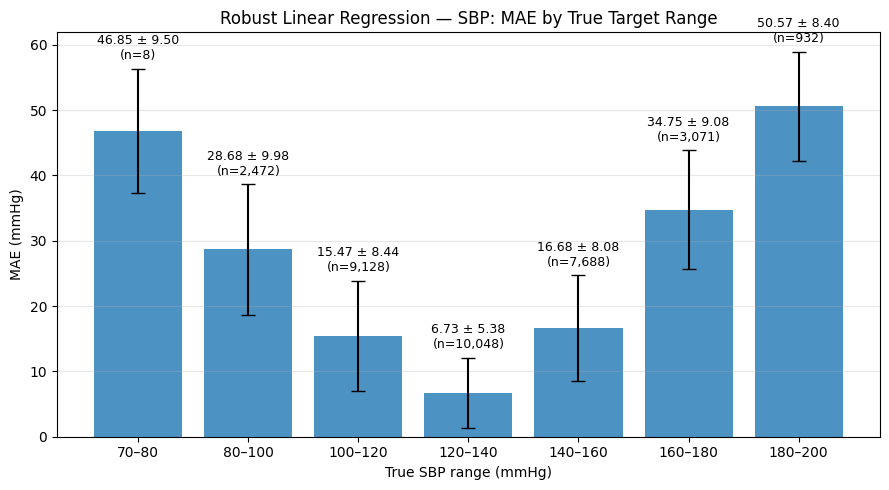

In [14]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 206.2261
MSE : 42529.2161
R²  : -98.8354
MAE : 62.7469


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


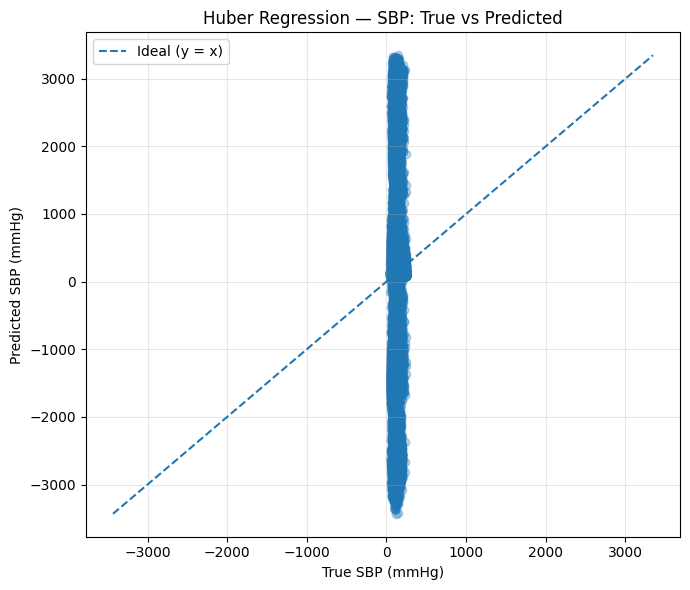

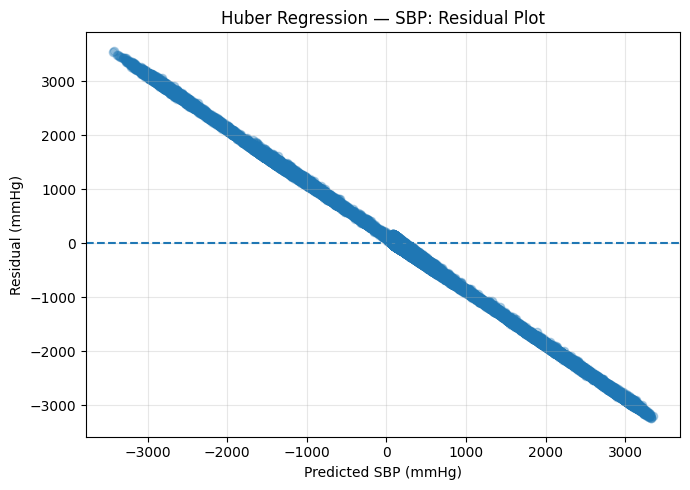

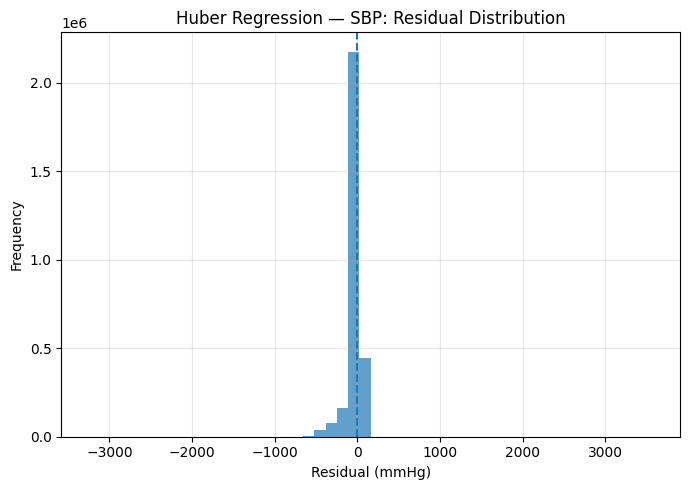

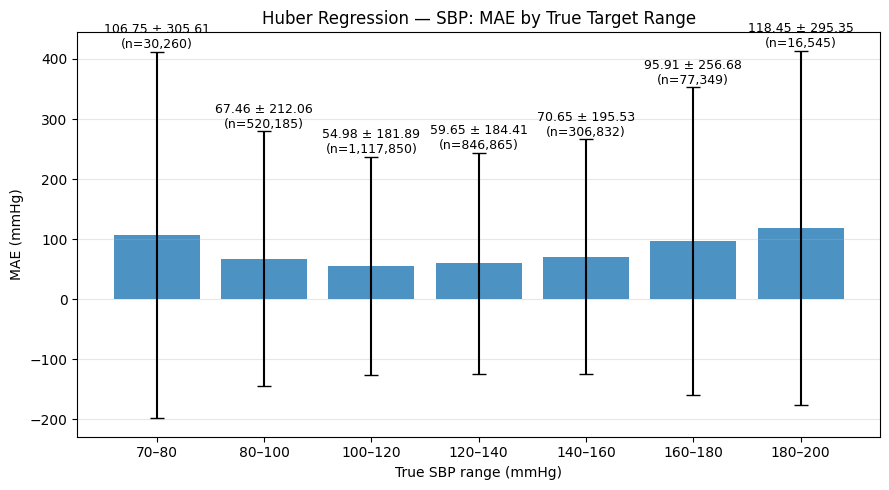

In [15]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — SBP
--------------------------------
RMSE: 20.1557
MSE : 406.2541
R²  : 0.2308
MAE : 15.6199


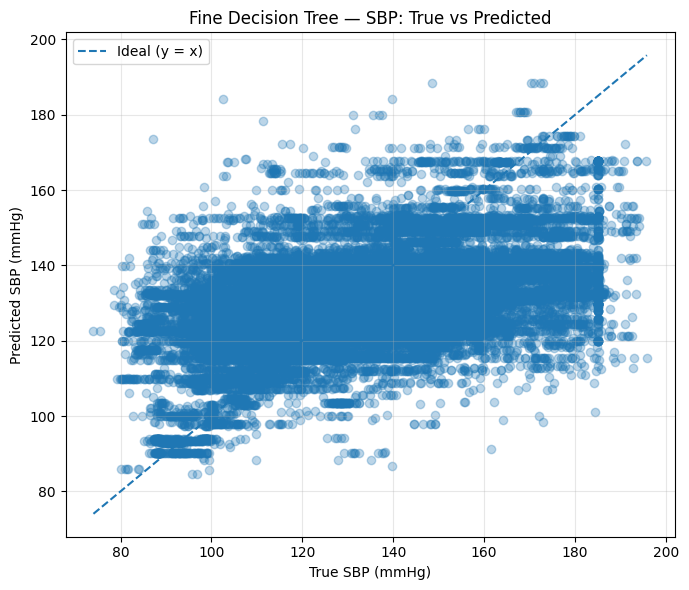

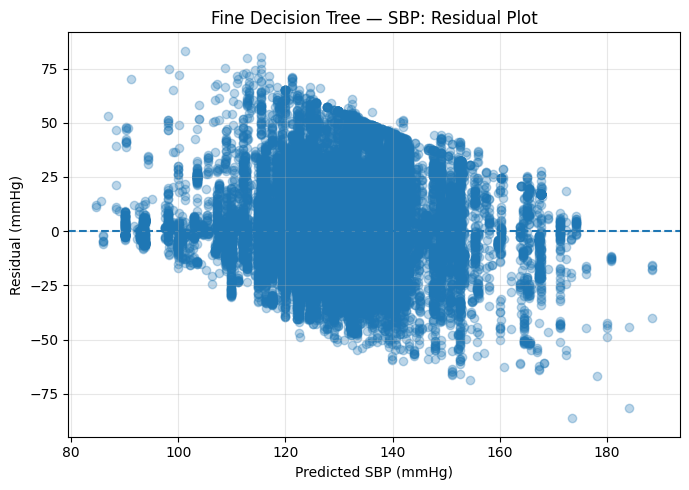

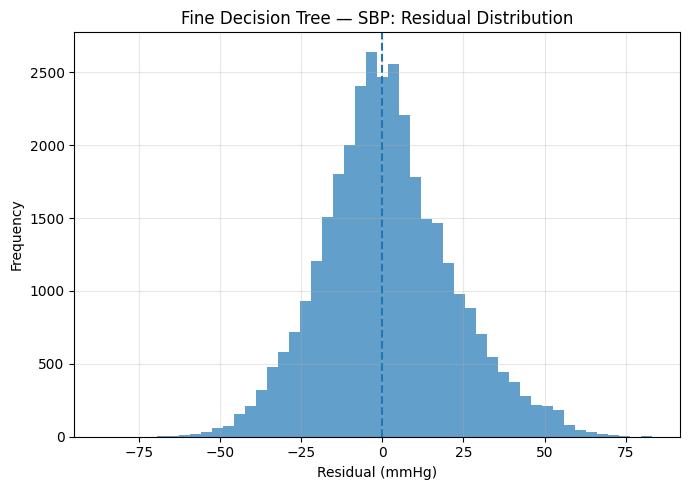

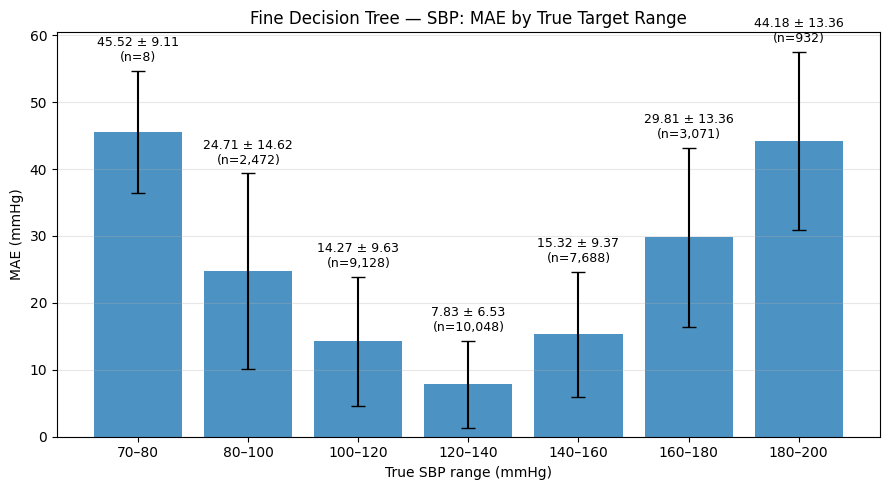

In [16]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 25.7272
MSE : 661.8896
R²  : -0.5538
MAE : 20.8928


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


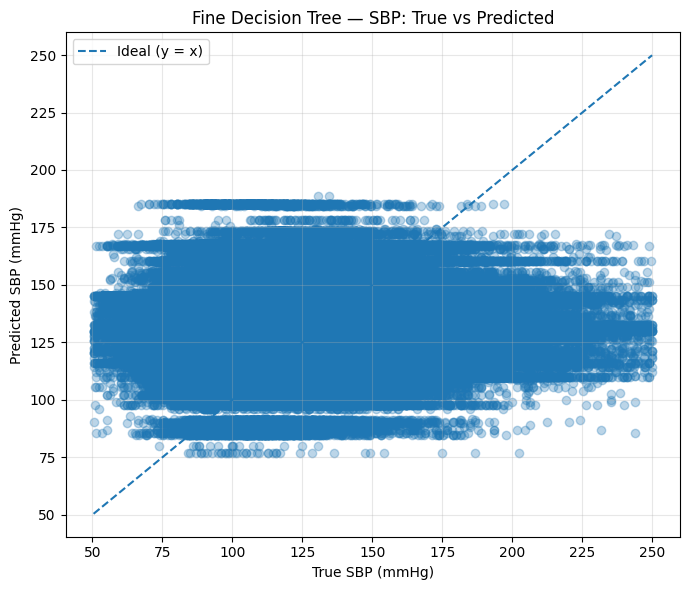

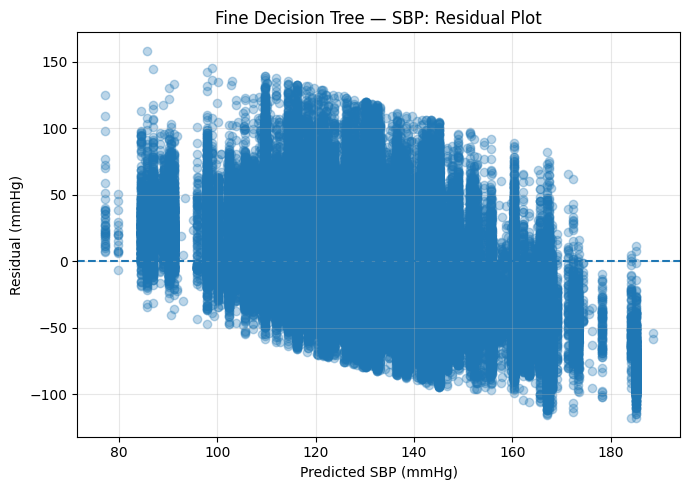

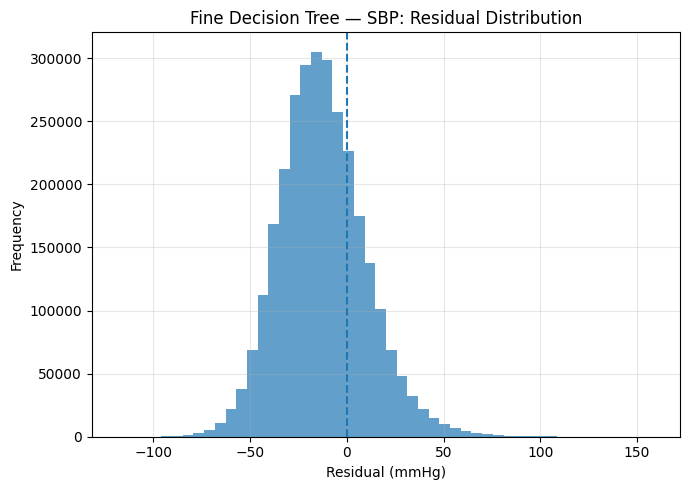

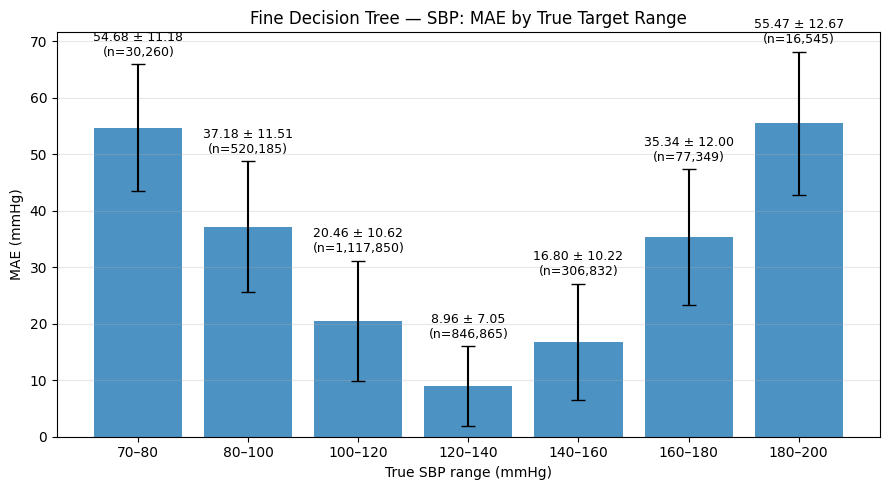

In [17]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — SBP
----------------------------
RMSE: 17.1526
MSE : 294.2112
R²  : 0.4429
MAE : 12.8607


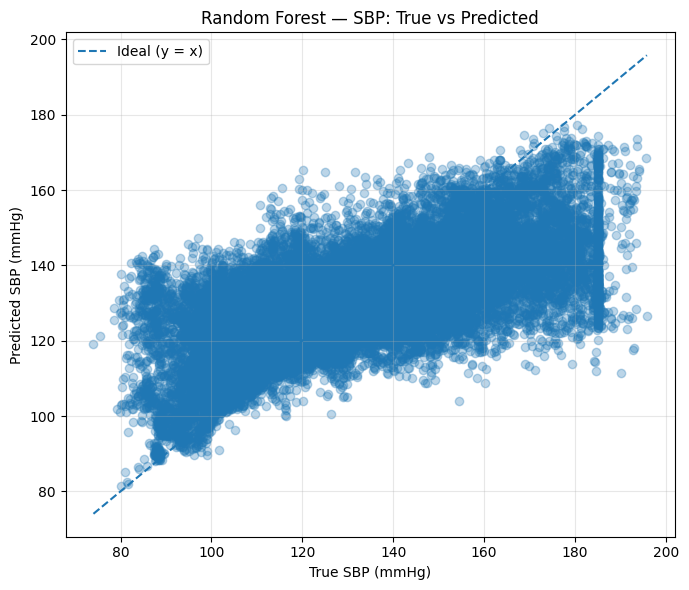

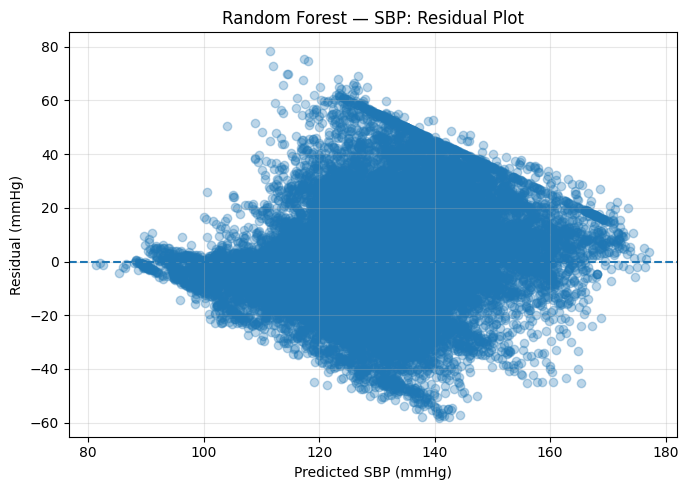

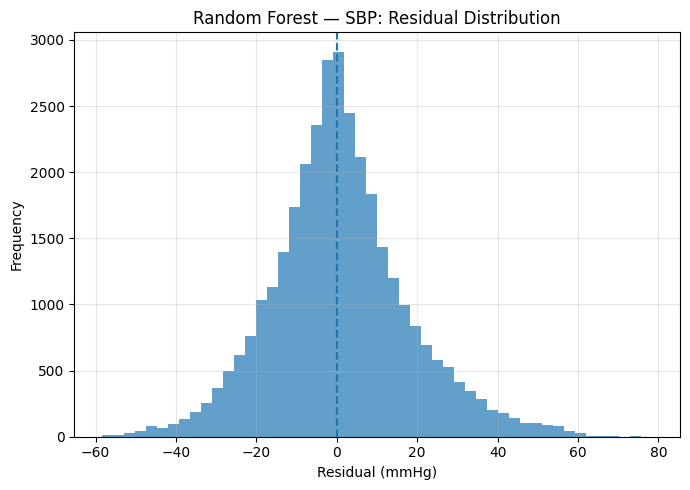

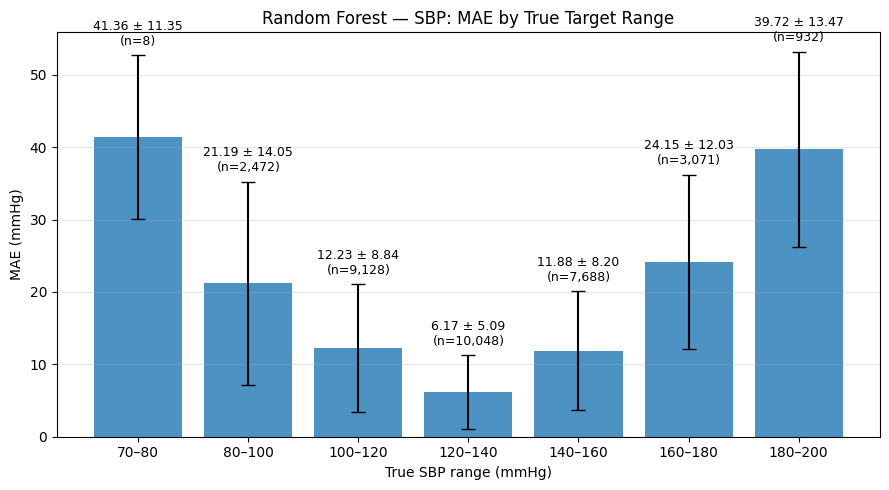

In [18]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 24.0562
MSE : 578.7000
R²  : -0.3585
MAE : 19.7445


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


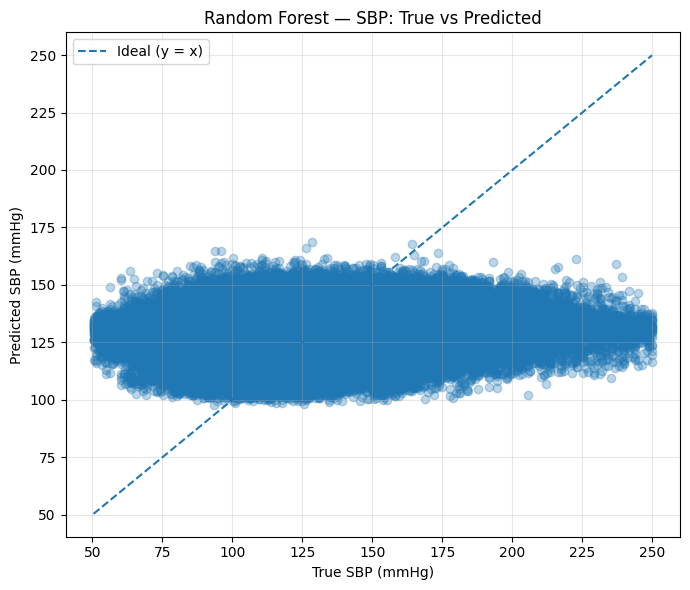

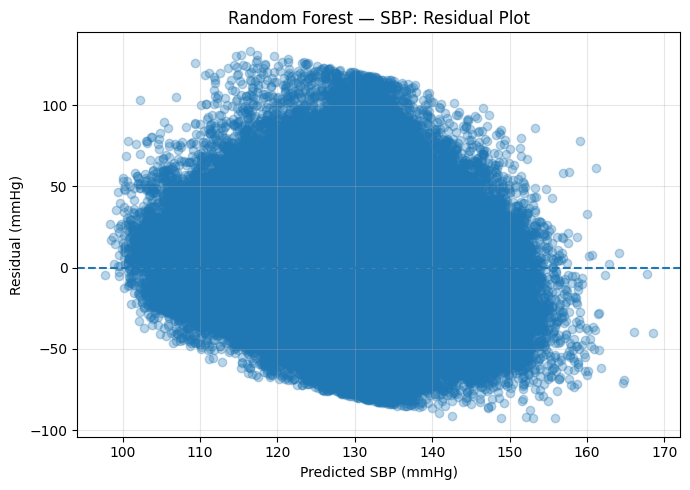

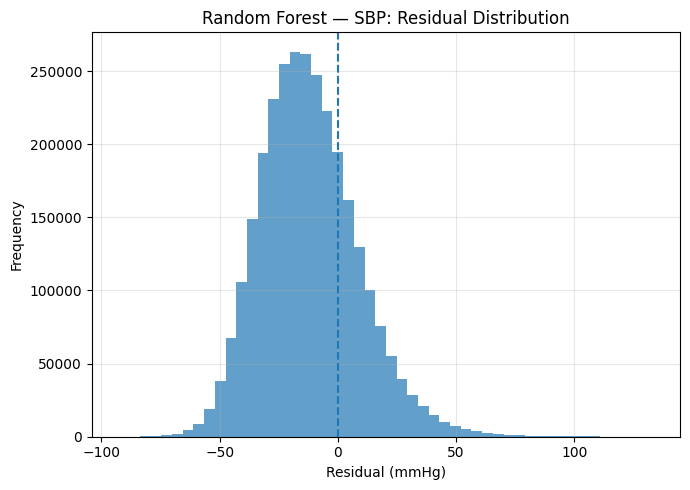

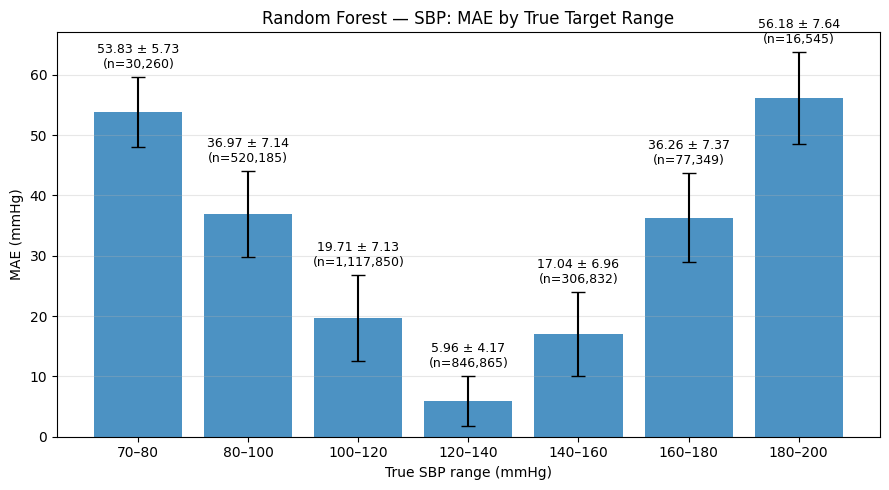

In [19]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — SBP
--------------------------------------
RMSE: 16.9866
MSE : 288.5444
R²  : 0.4537
MAE : 12.5363


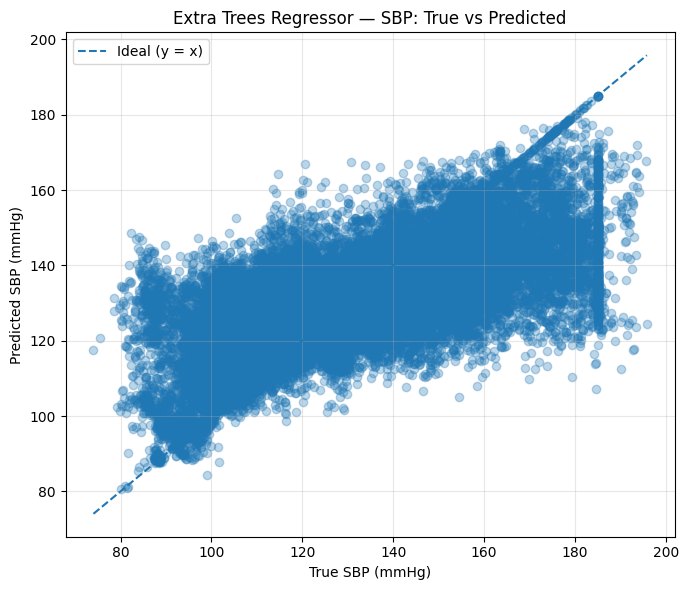

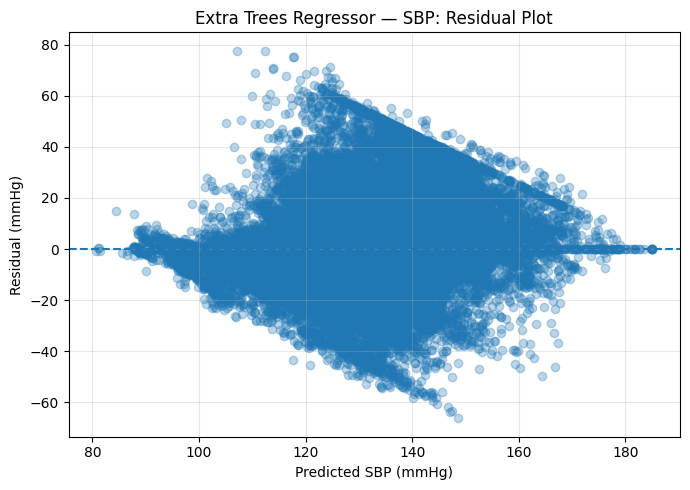

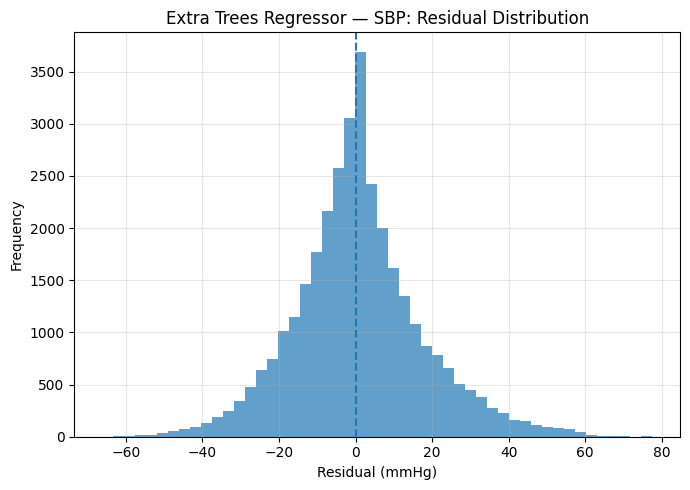

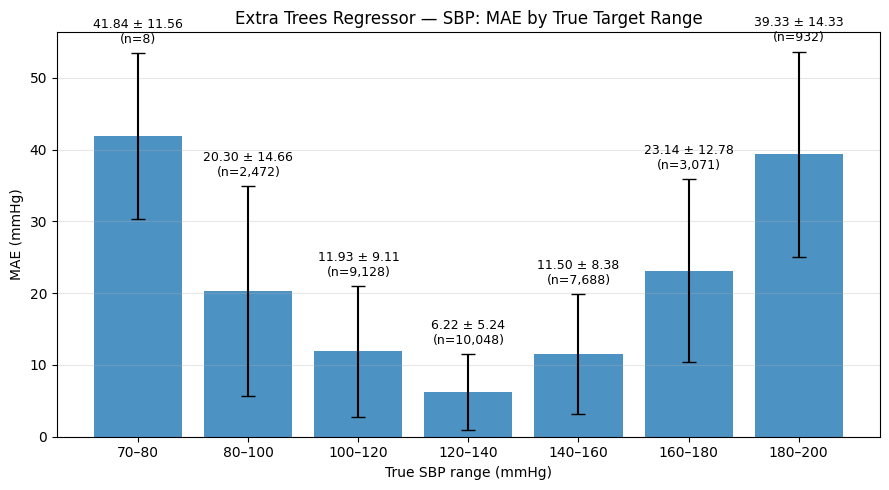

In [20]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 24.0385
MSE : 577.8474
R²  : -0.3565
MAE : 19.7353


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


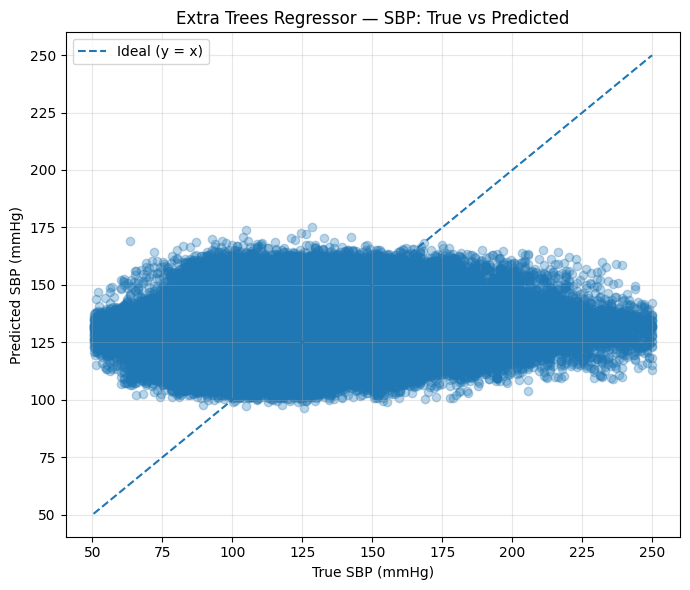

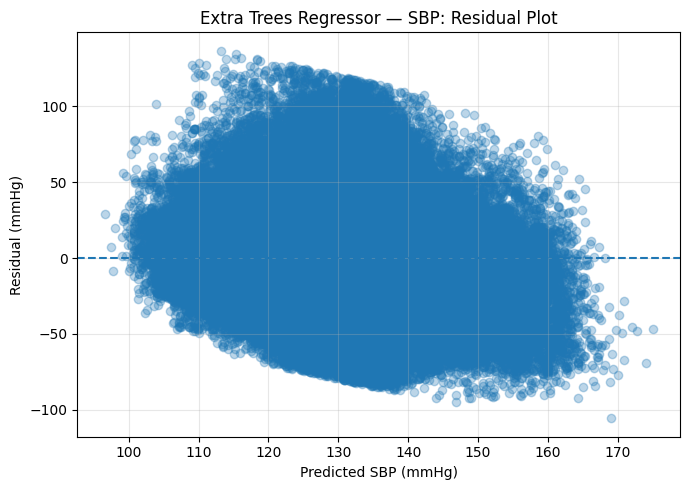

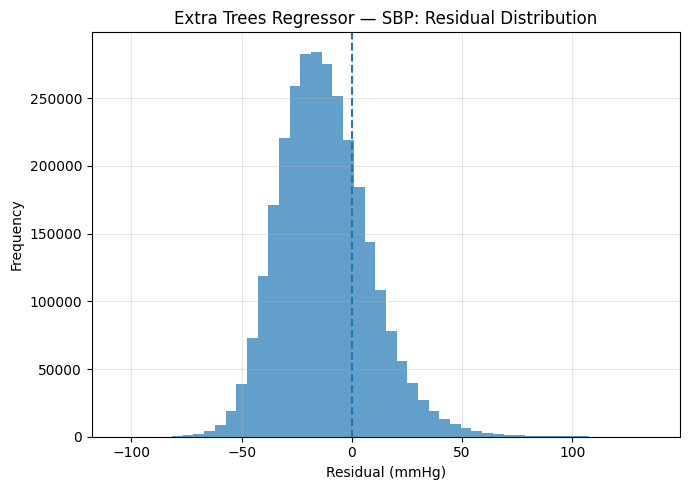

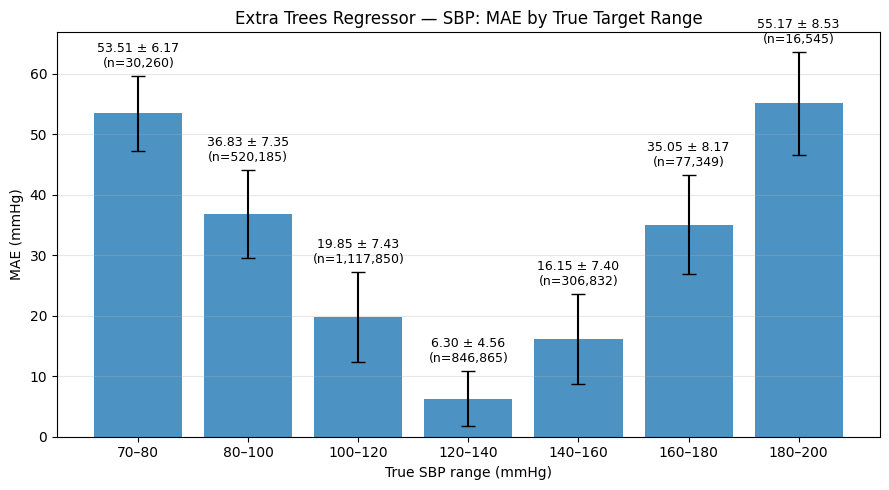

In [21]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — SBP
---------------------
RMSE: 18.4341
MSE : 339.8157
R²  : 0.3566
MAE : 14.2331


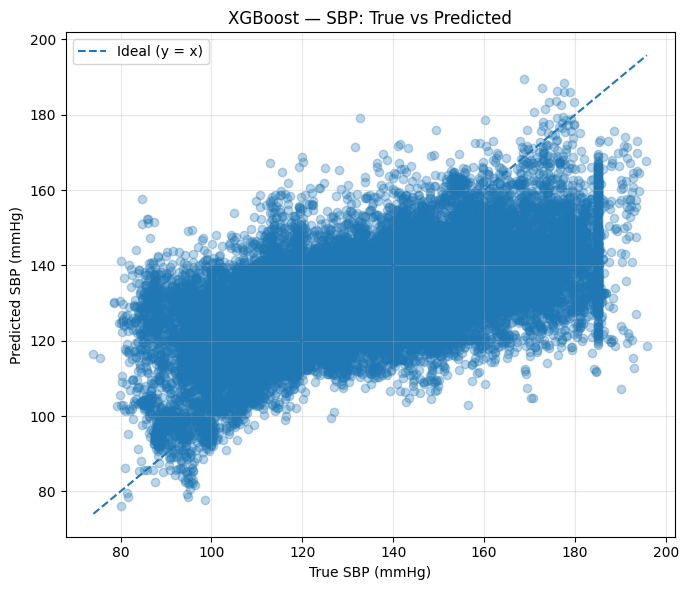

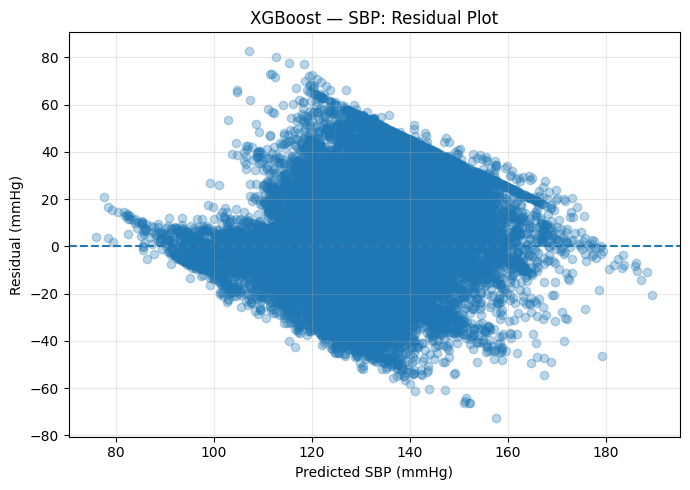

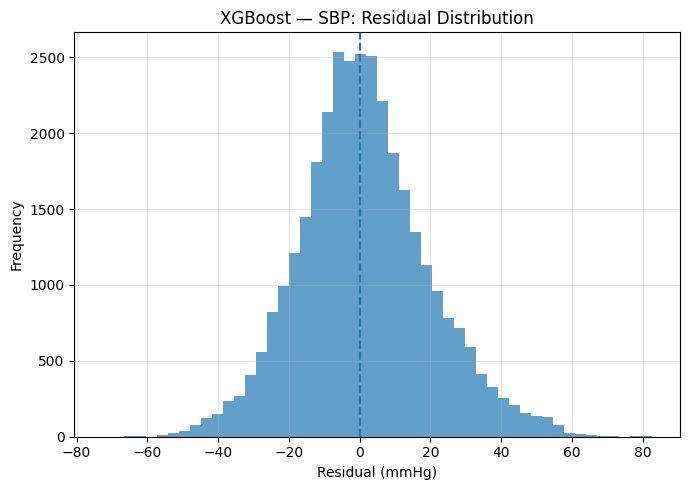

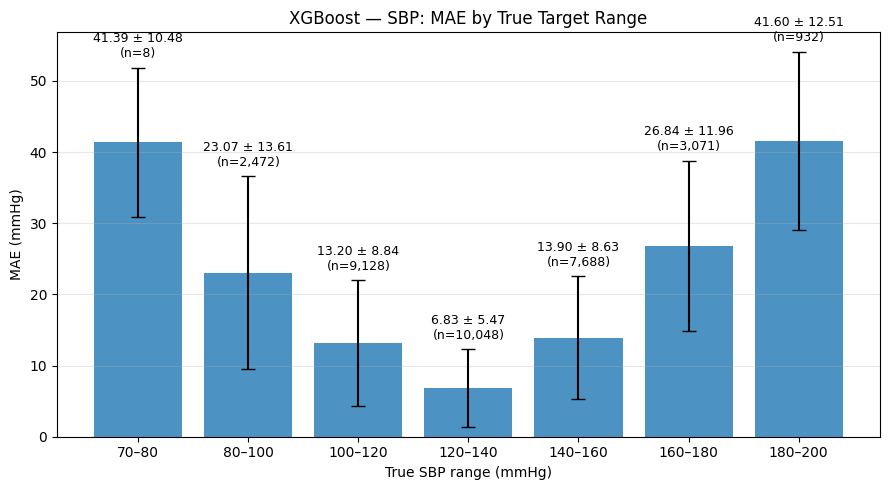

In [22]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 23.3665
MSE : 545.9941
R²  : -0.2817
MAE : 18.7722


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


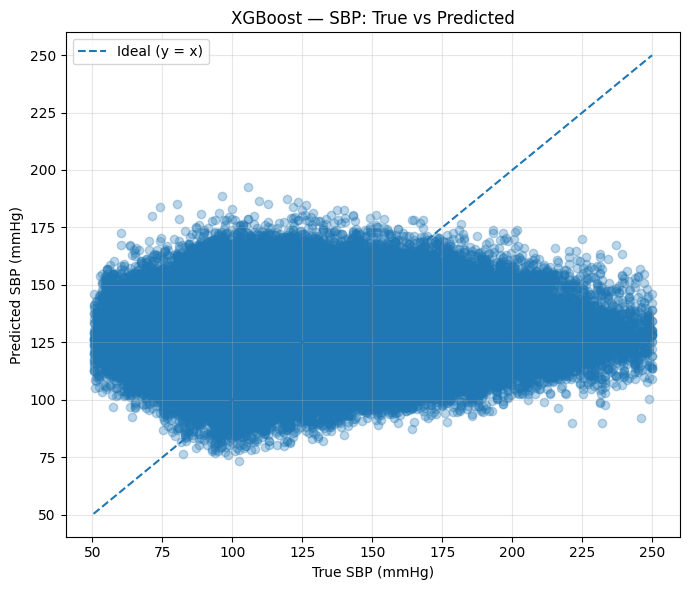

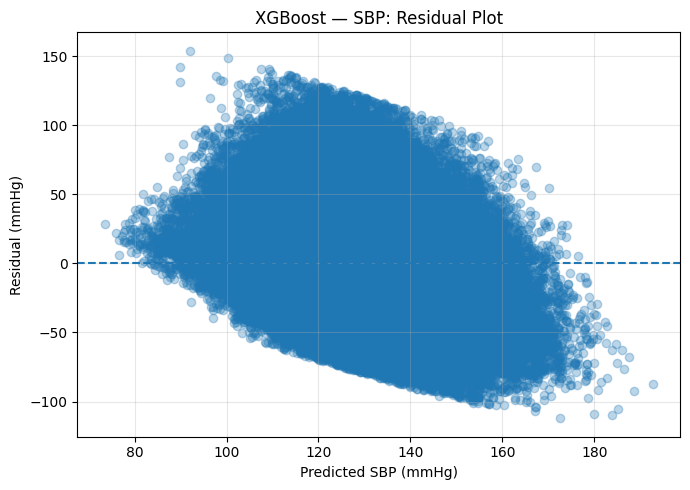

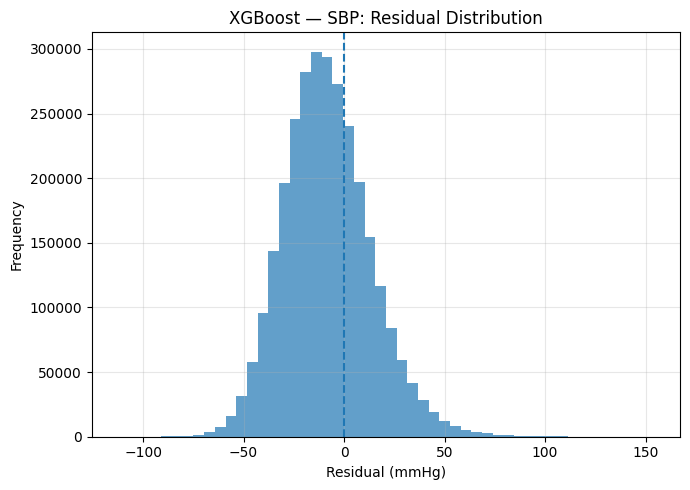

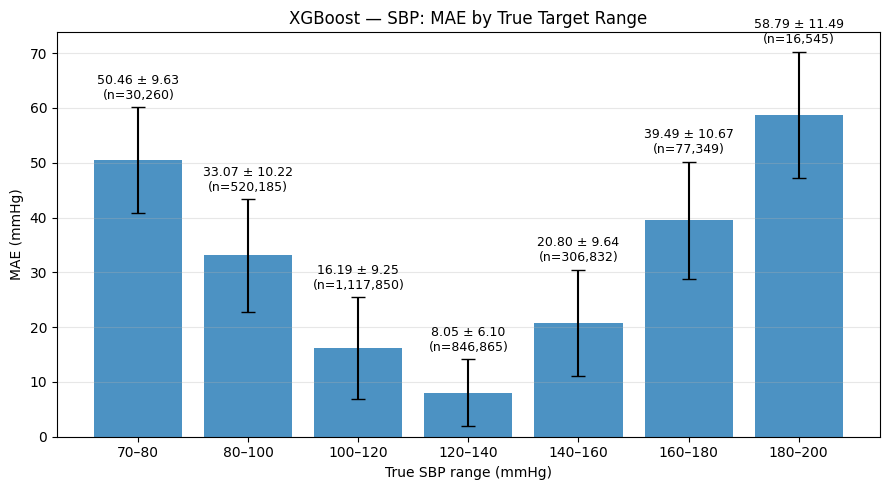

In [23]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   7.4s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   7.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   1.9s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   3.5s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   2.4s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   5.8s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   4.0s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   5.9s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   7.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total ti

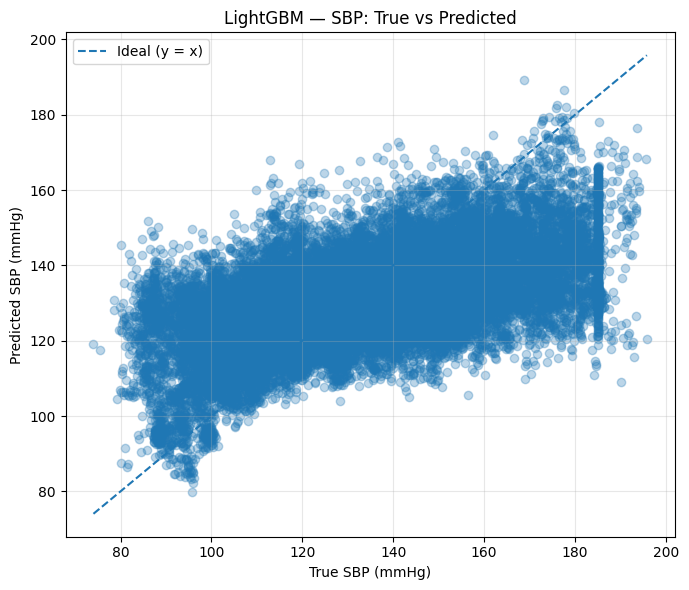

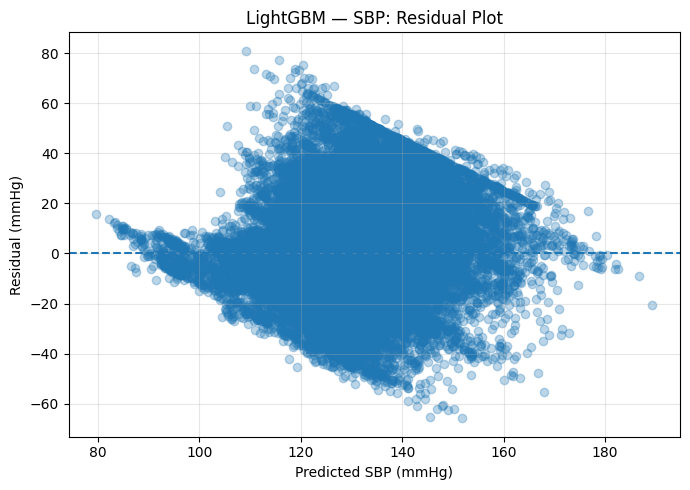

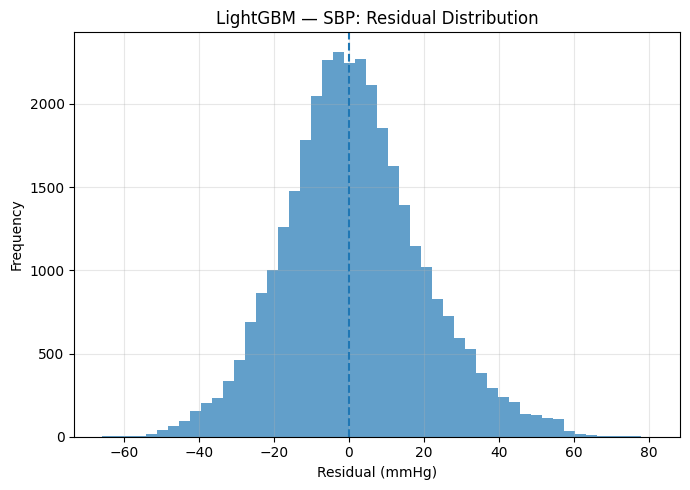

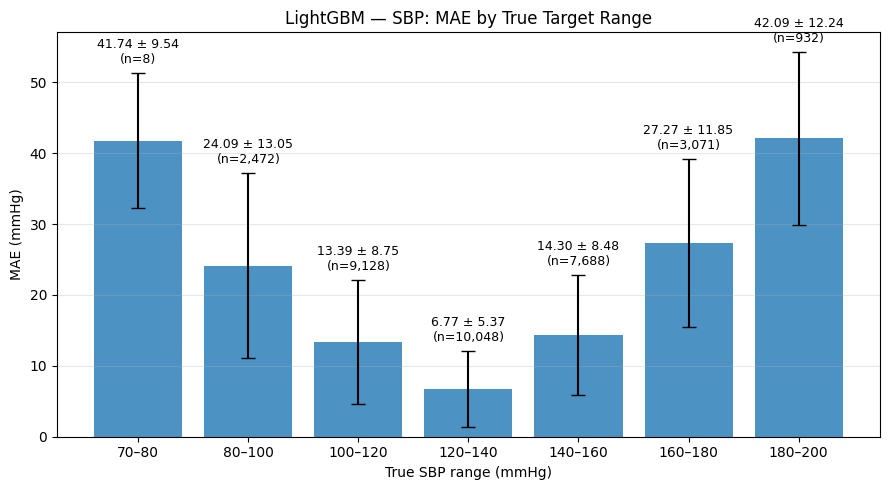

In [24]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 24.4418
MSE : 597.4037
R²  : -0.4024
MAE : 19.7540


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


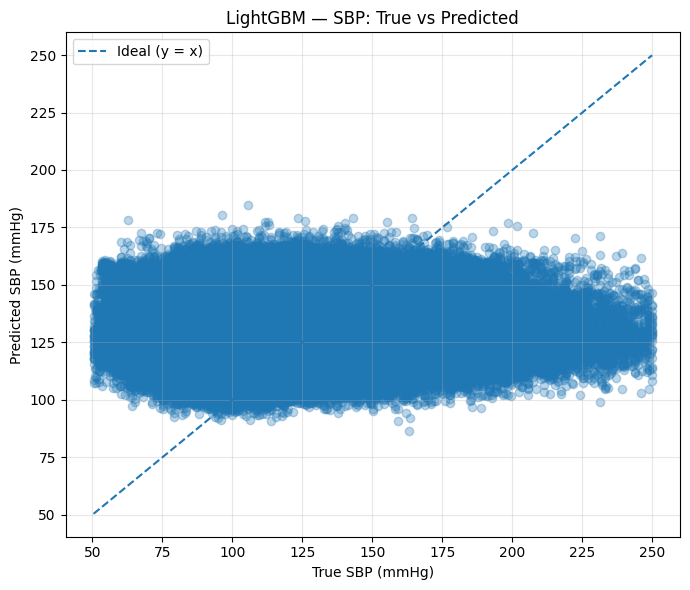

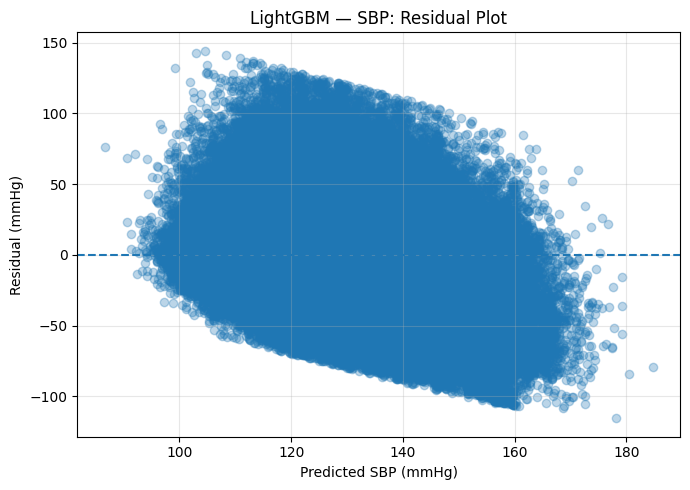

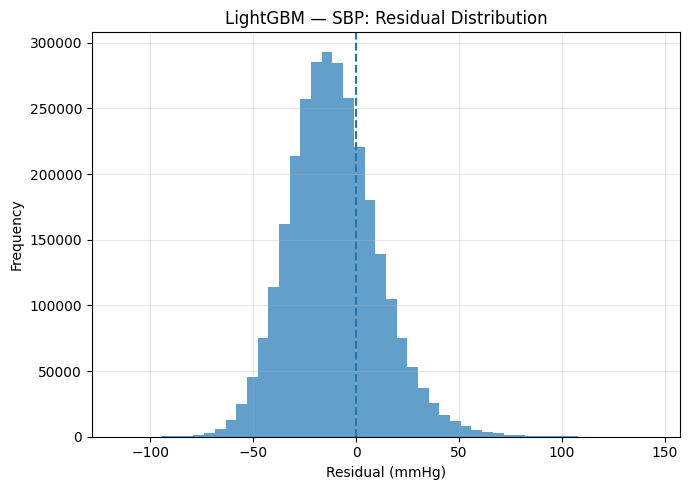

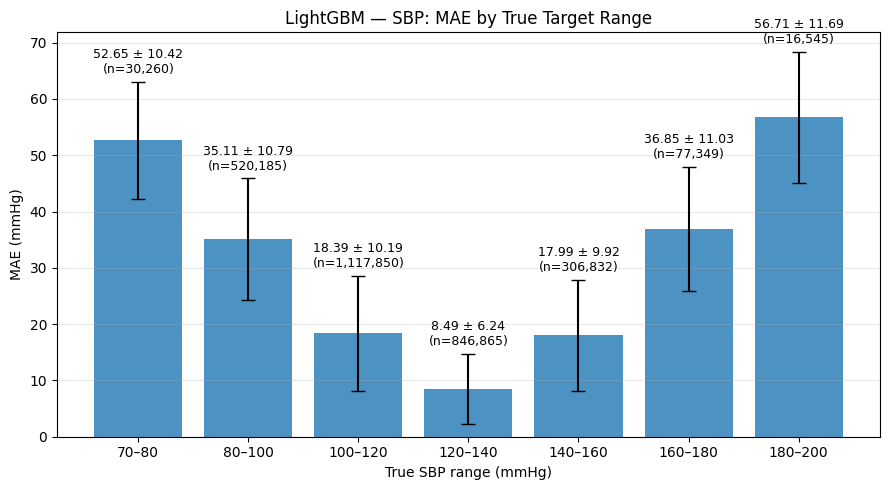

In [25]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

Best parameters:
{'kernel': 1**2 * Matern(length_scale=2, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — SBP
--------------------------------
RMSE: 19.2802
MSE : 371.7258
R²  : 0.2962
MAE : 14.9915


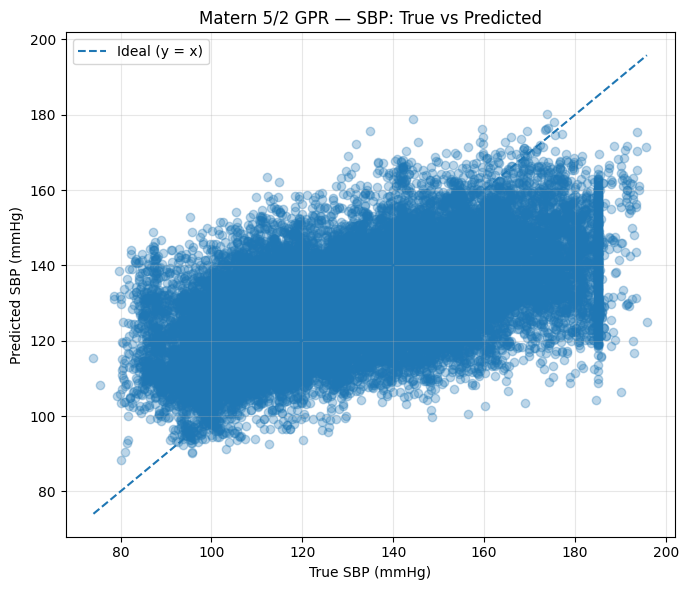

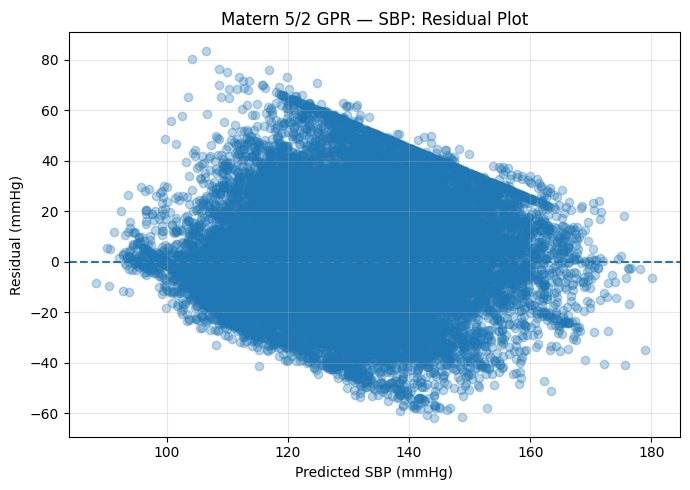

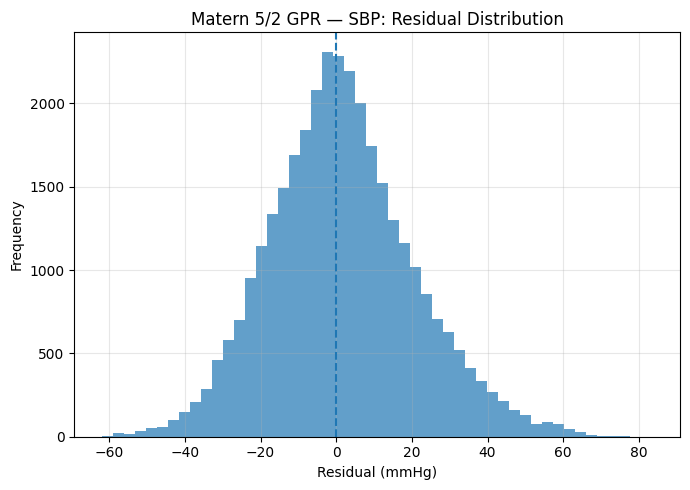

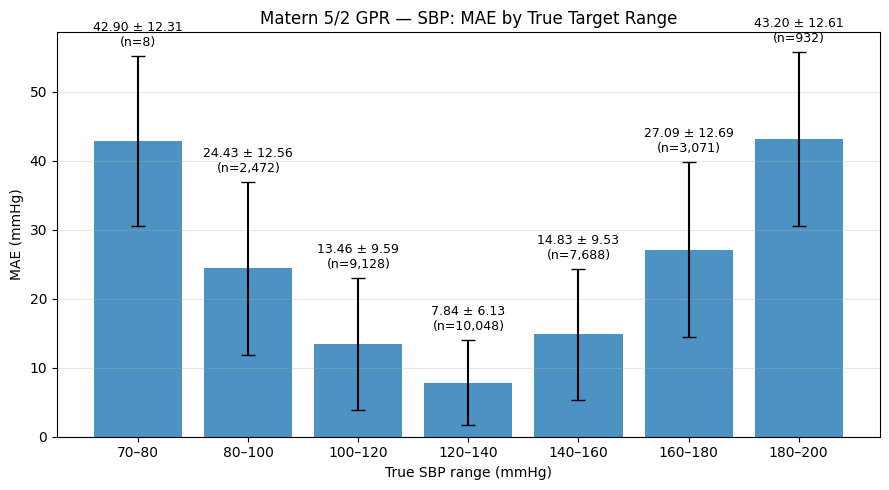

In [10]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 23.4070
MSE : 547.8862
R²  : -0.2861
MAE : 19.1779


/tmp/ipykernel_473131/27689683.py:78: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


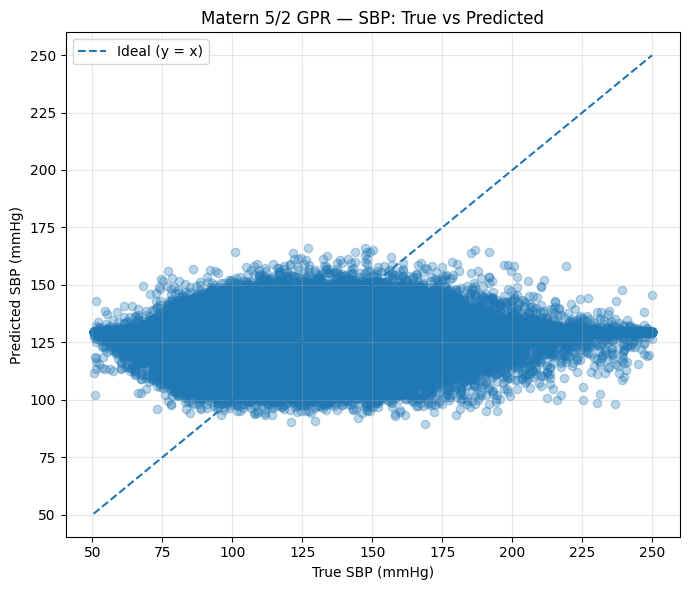

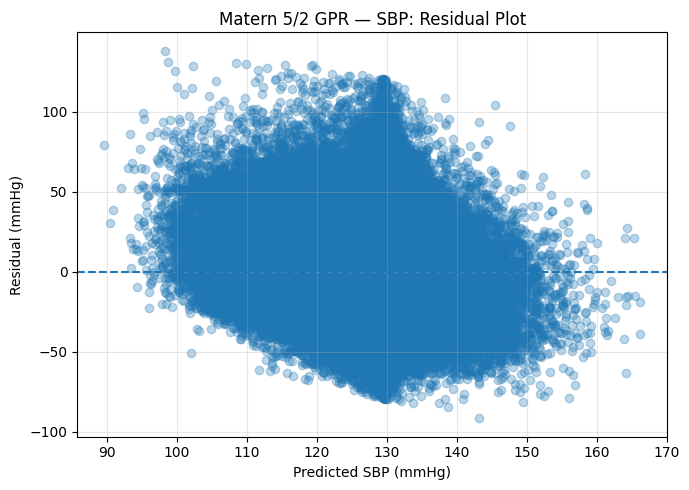

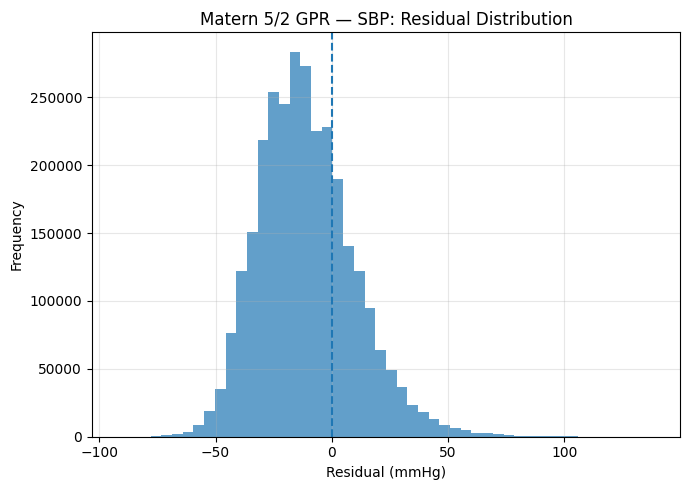

In [27]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a bette

Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=2) + WhiteKernel(noise_level=1)}

Rational Quadratic GPR — SBP
------------------------------------------
RMSE: 19.1983
MSE : 368.5762
R²  : 0.3021
MAE : 14.8316


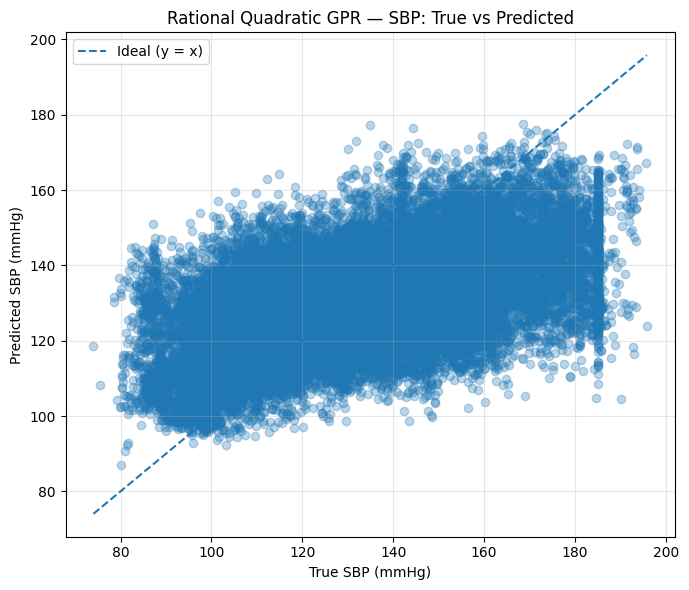

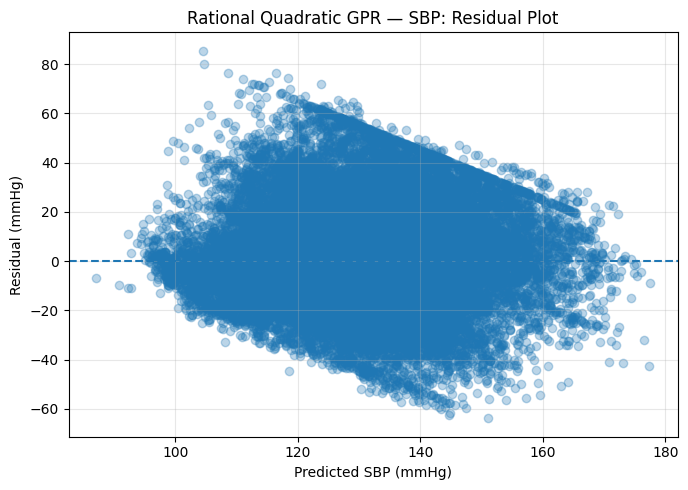

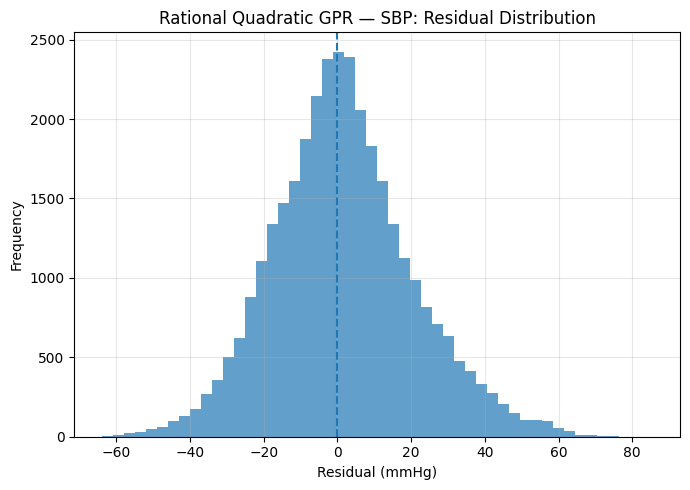

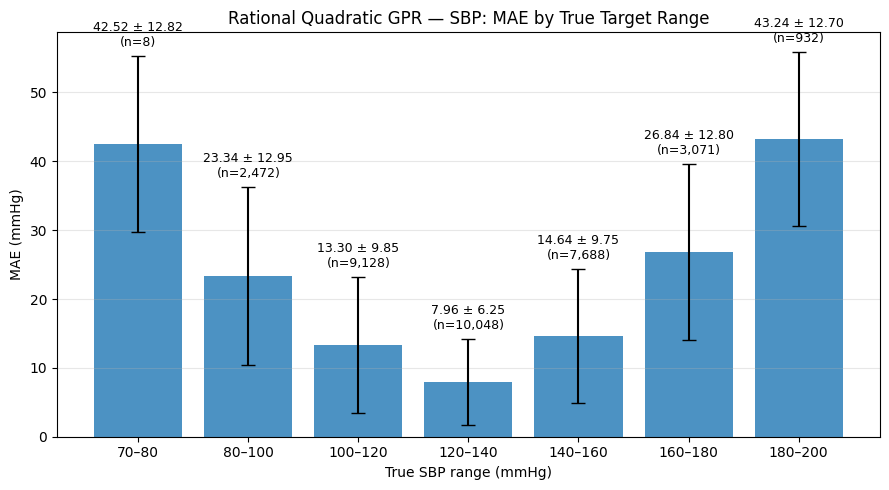

In [11]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 22.2655
MSE : 495.7528
R²  : -0.1638
MAE : 17.9970


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


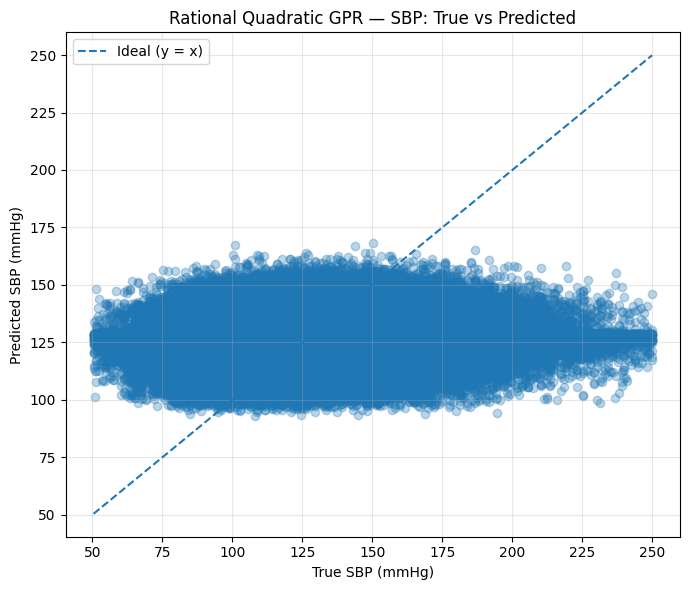

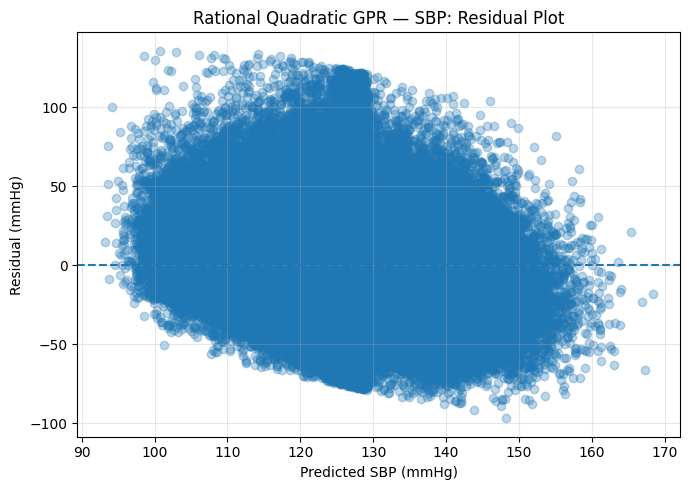

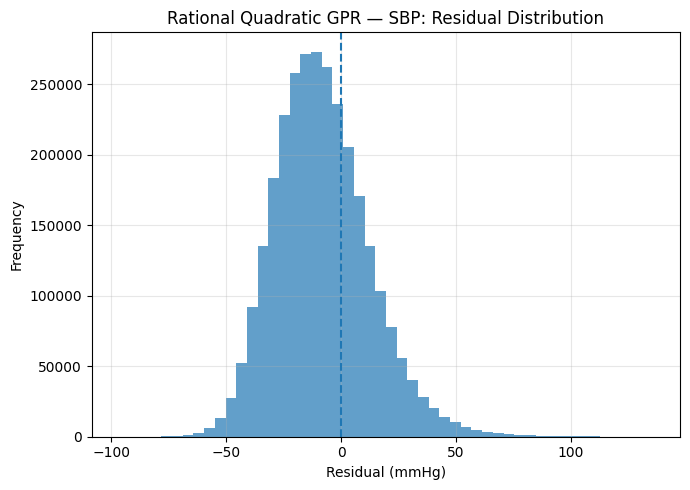

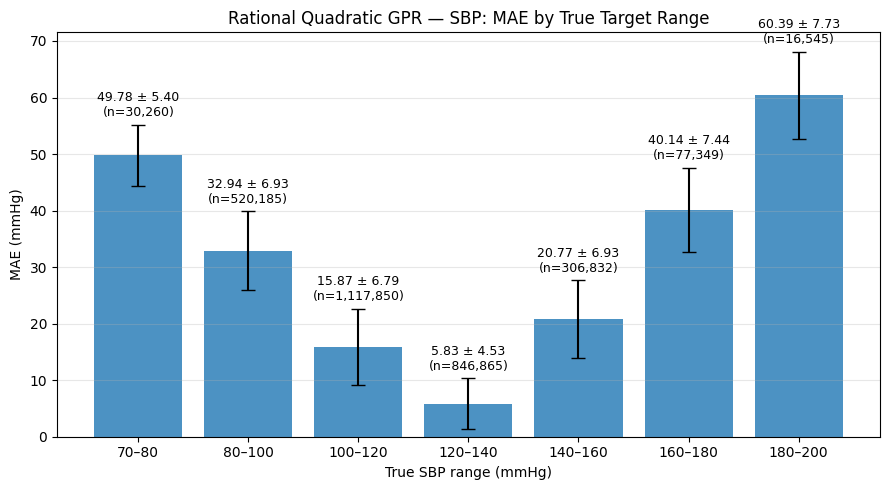

In [12]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

In [10]:

def print_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"R²  : {r2:.4f}")
    print(f"MAE : {mae:.4f}")
    

from matplotlib import pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt


def plot_regression_results(
    y_true,
    y_pred,
    model_name,
    target_name
):

    # Convert to NumPy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    residuals = y_true - y_pred

    # ----------------------------------------
    # 1. TRUE VS PREDICTED
    # ----------------------------------------

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.3
    )

    min_val = min(
        y_true.min(),
        y_pred.min()
    )

    max_val = max(
        y_true.max(),
        y_pred.max()
    )

    # Ideal y = x line
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        label="Ideal (y = x)"
    )

    plt.xlabel(
        f"True {target_name} (mmHg)"
    )

    plt.ylabel(
        f"Predicted {target_name} (mmHg)"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"True vs Predicted"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 2. RESIDUAL VS PREDICTED
    # ----------------------------------------

    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_pred,
        residuals,
        alpha=0.3
    )

    # Zero-error line
    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        f"Predicted {target_name} (mmHg)"
    )

    plt.ylabel(
        "Residual (mmHg)"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"Residual Plot"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 3. RESIDUAL DISTRIBUTION
    # ----------------------------------------

    plt.figure(figsize=(7, 5))

    plt.hist(
        residuals,
        bins=50,
        alpha=0.7
    )

    # Zero-error line
    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        "Residual (mmHg)"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"Residual Distribution"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 4. MAE VS TRUE TARGET RANGE
    #    WITH ERROR BARS
    # ----------------------------------------

    if target_name.upper() == "DBP":

        bins = [
            50,
            60,
            70,
            80,
            90,
            100,
            120,
            150
        ]

    else:

        # SBP
        bins = [
            70,
            80,
            100,
            120,
            140,
            160,
            180,
            200
        ]


    mae_values = []
    error_std = []
    sample_counts = []
    range_labels = []


    for i in range(len(bins) - 1):

        lower = bins[i]
        upper = bins[i + 1]

        mask = (
            (y_true >= lower) &
            (y_true < upper)
        )

        count = np.sum(mask)

        # Skip range if there are no samples
        if count == 0:
            continue


        # ----------------------------------------
        # Absolute errors for this BP range
        # ----------------------------------------

        absolute_errors = np.abs(
            y_true[mask] -
            y_pred[mask]
        )


        # Mean Absolute Error
        mae = np.mean(
            absolute_errors
        )


        # Standard deviation of absolute errors
        std = np.std(
            absolute_errors
        )


        mae_values.append(mae)
        error_std.append(std)
        sample_counts.append(count)

        range_labels.append(
            f"{lower}–{upper}"
        )


    # ----------------------------------------
    # Plot MAE + error bars
    # ----------------------------------------

    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        range_labels,
        mae_values,
        yerr=error_std,
        capsize=5,
        alpha=0.8
    )


    plt.xlabel(
        f"True {target_name} range (mmHg)"
    )

    plt.ylabel(
        "MAE (mmHg)"
    )

    plt.title(
        f"{model_name} — {target_name}: "
        f"MAE by True Target Range"
    )


    # ----------------------------------------
    # Add MAE ± SD and sample count
    # ----------------------------------------

    for bar, mae, std, count in zip(
        bars,
        mae_values,
        error_std,
        sample_counts
    ):

        plt.text(
            bar.get_x() +
            bar.get_width() / 2,

            bar.get_height()+std+1,

            f"{mae:.2f} ± {std:.2f}\n"
            f"(n={count:,})",

            ha="center",
            va="bottom",
            fontsize=9
        )


    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


import numpy as np

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV


# ============================================================
# BATCHED ANN / MLP PREDICTION
# ============================================================

def predict_ann_in_batches(
    model,
    X,
    y_test,
    target_name,
    model_name,
    batch_size=10000
):

    # Preallocate prediction array
    y_test_pred = np.empty(
        len(X),
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Predict batch by batch
    # --------------------------------------------------------

    for start in range(0, len(X), batch_size):

        end = min(
            start + batch_size,
            len(X)
        )

        X_batch = X[start:end]

        y_test_pred[start:end] = model.predict(
            X_batch
        )

        print(
            f"Processed {end:,} / {len(X):,}"
        )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    print(
        f"\n{model_name} — {target_name}"
    )

    print("------------------------------------")

    print_metrics(
        y_test,
        y_test_pred
    )

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------

    plot_regression_results(
        y_test,
        y_test_pred,
        model_name,
        target_name=target_name
    )

    return y_test_pred


# ============================================================
# ANN / MLP REGRESSOR
# ============================================================

def ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    target_name,
    n_ann=5000,
    cv=3,
    batch_size=10000
):

    # ========================================================
    # 1. TAKE A MANAGEABLE SUBSET
    # ========================================================

    rng = np.random.RandomState(42)

    n_samples = min(
        n_ann,
        len(X_dev)
    )

    indices = rng.choice(
        len(X_dev),
        size=n_samples,
        replace=False
    )

    # --------------------------------------------------------
    # Works for pandas DataFrame and NumPy arrays
    # --------------------------------------------------------

    if hasattr(X_dev, "iloc"):
        X_ann = X_dev.iloc[indices]
    else:
        X_ann = X_dev[indices]

    if hasattr(y_dev, "iloc"):
        y_ann = y_dev.iloc[indices]
    else:
        y_ann = y_dev[indices]

    print(
        f"ANN training samples: {len(X_ann):,}"
    )

    # ========================================================
    # 2. ANN / MLP
    # ========================================================

    ann_model = MLPRegressor(
        random_state=42,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    )

    # ========================================================
    # 3. HYPERPARAMETER GRID
    # ========================================================

    param_grid = {

        "hidden_layer_sizes": [
            (64, 32),
            (128, 64),
            (64, 32, 16)
        ],

        "activation": [
            "relu"
        ],

        "alpha": [
            0.0001,
            0.001,
            0.01
        ],

        "learning_rate_init": [
            0.001,
            0.01
        ],

        "batch_size": [
            256,
            512
        ]
    }

    # ========================================================
    # 4. GRIDSEARCHCV
    # ========================================================

    grid_ann = GridSearchCV(
        estimator=ann_model,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=8,
        verbose=1
    )

    # ========================================================
    # 5. FIT
    # ========================================================

    print("\nStarting ANN / MLP GridSearch...")

    grid_ann.fit(
        X_ann,
        y_ann
    )

    # ========================================================
    # 6. BEST PARAMETERS
    # ========================================================

    print("\nBest parameters:")

    print(
        grid_ann.best_params_
    )

    print(
        "\nBest CV RMSE:",
        np.sqrt(
            -grid_ann.best_score_
        )
    )

    # ========================================================
    # 7. GET BEST TRAINED MODEL
    # ========================================================

    best_ann = grid_ann.best_estimator_

    print("\nBest ANN / MLP model:")
    print(best_ann)

    # ========================================================
    # 8. BATCHED TEST PREDICTION
    # ========================================================

    print(
        f"\nStarting batched prediction "
        f"on {len(X_test):,} samples..."
    )

    y_test_pred = predict_ann_in_batches(
        model=best_ann,
        X=X_test,
        y_test=y_test,
        target_name=target_name,
        model_name="ANN / MLP Regressor",
        batch_size=batch_size
    )

    # ========================================================
    # 9. RETURN
    # ========================================================

    return (
        grid_ann,
        y_test_pred
    )

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.01, 'batch_size': 256, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.001}

Best CV RMSE: 20.083122993757776

Best ANN / MLP model:
MLPRegressor(alpha=0.01, batch_size=256, early_stopping=True,
             hidden_layer_sizes=(64, 32, 16), max_iter=300, n_iter_no_change=20,
             random_state=42)

Starting batched prediction on 33,347 samples...
Processed 10,000 / 33,347
Processed 20,000 / 33,347
Processed 30,000 / 33,347
Processed 33,347 / 33,347

ANN / MLP Regressor — SBP
------------------------------------
RMSE: 22.9575
MSE : 527.0449
R²  : 0.0021
MAE : 15.6869


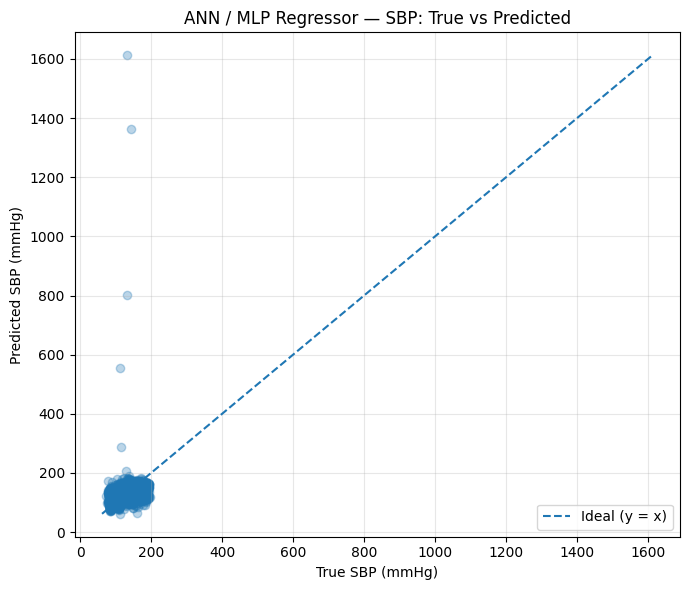

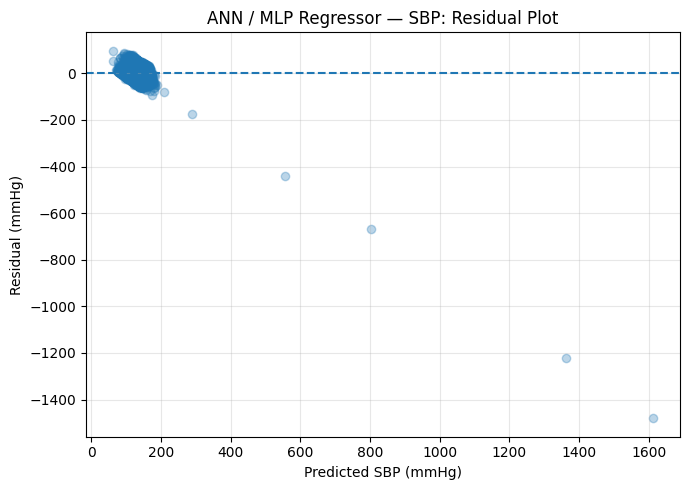

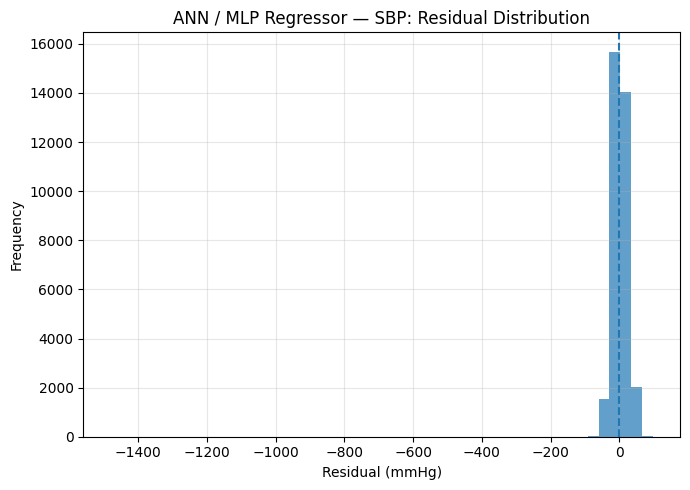

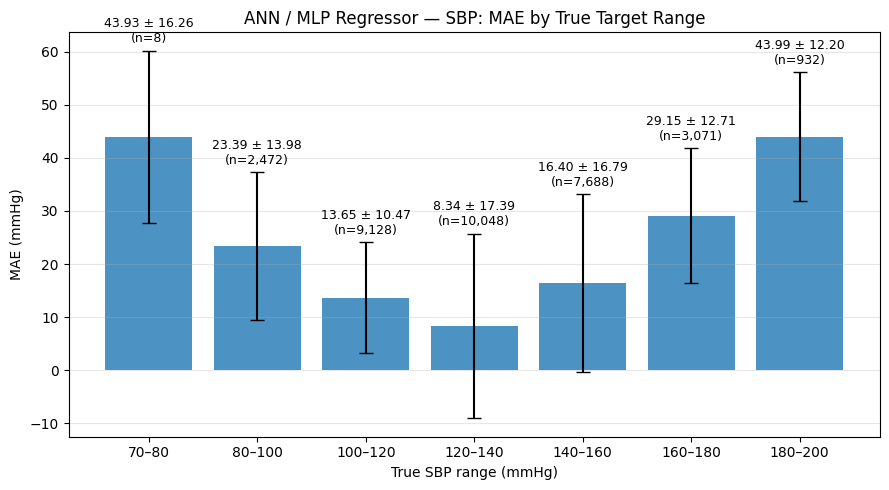

In [11]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 1315.6963
MSE : 1731056.7205
R²  : -4062.5783
MAE : 453.0228


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


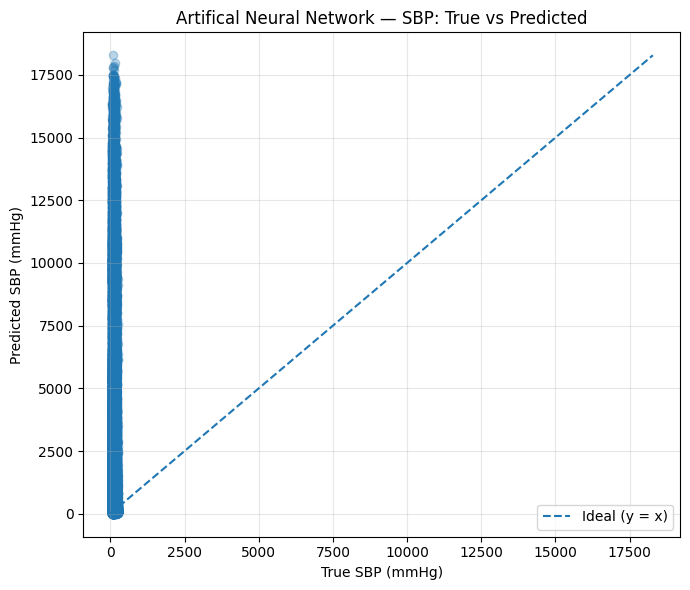

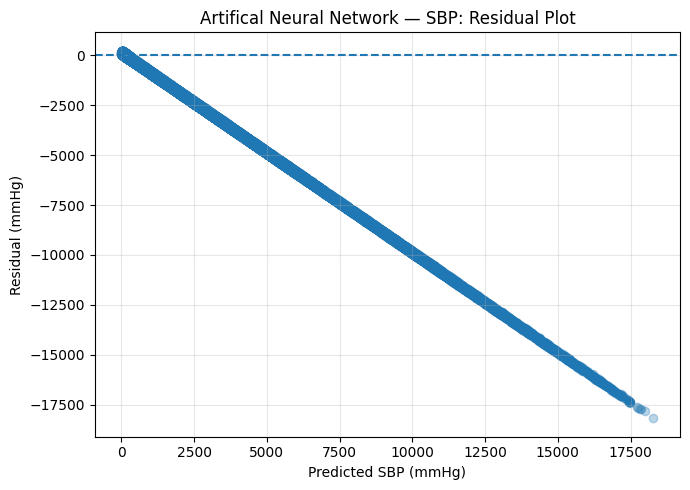

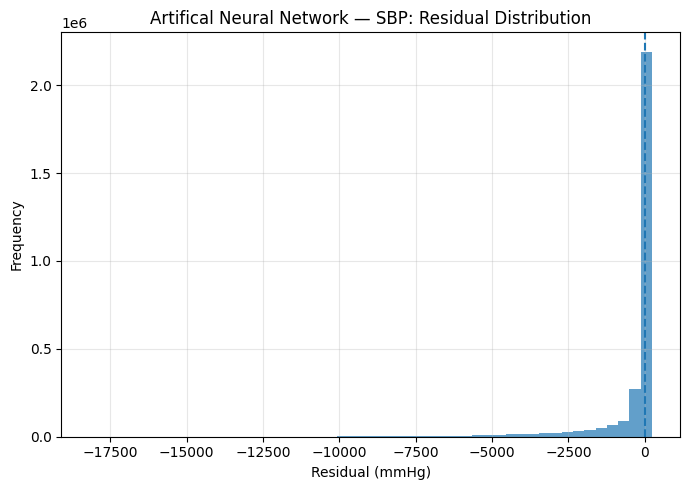

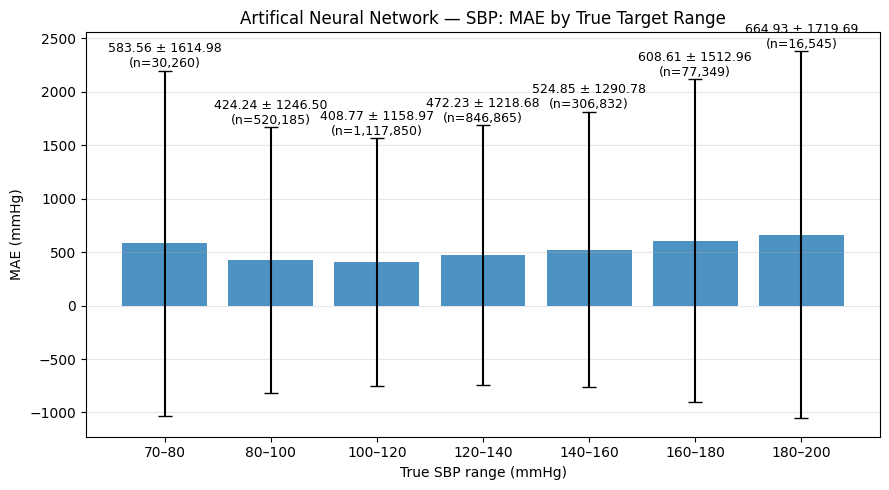

In [12]:
y_pred_vitaldb = predict_gpr_in_batches(
    ann_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)